# Chapter 18: Advanced Plotting with Seaborn

**Companion notebook** for *Beginner's Guide to Pandas* by Ravi Shankar

Run each cell in order. Exercises are at the end.

In [1]:
import pandas as pd
import numpy as np

# Advanced Plotting with Seaborn

Seaborn is a Python library built on Matplotlib that specializes in statistical visualizations. It handles complex plots with minimal code while maintaining publication-quality output. Combined with pandas, Seaborn enables efficient exploratory data analysis and professional presentations.

## Getting Started: Setup and Sample Data

Before creating visualizations, import the necessary libraries and prepare your data:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create sample sales data
sales = pd.DataFrame({
    'region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West'] * 5,
    'units_sold': np.random.randint(10, 100, 40),
    'revenue': np.random.normal(5000, 1500, 40),
    'product_type': np.random.choice(['Product_A', 'Product_B', 'Product_C'], 40),
    'date': pd.date_range('2023-01-01', periods=40, freq='W')
})

print(sales.head())

  region  units_sold      revenue product_type       date
0  North          53  5160.417725    Product_C 2023-01-01
1  South          47  2804.566012    Product_C 2023-01-08
2   East          73  6599.062219    Product_B 2023-01-15
3   West          54  4983.127265    Product_B 2023-01-22
4  North          52  6713.149726    Product_B 2023-01-29


**Output:**
```
  region  units_sold      revenue product_type       date
0  North          53  5160.417725    Product_C 2023-01-01
1  South          47  2804.566012    Product_C 2023-01-08
2   East          73  6599.062219    Product_B 2023-01-15
3   West          54  4983.127265    Product_B 2023-01-22
4  North          52  6713.149726    Product_B 2023-01-29
```

---

## Scatter Plots: Exploring Relationships Between Variables

Scatter plots display relationships between two numeric variables, with each point representing one observation. Use the `hue` parameter to add a third dimension by coloring points by category.

**What is `hue`?** The `hue` parameter groups data by a categorical column and assigns different colors to each group, revealing patterns across categories.

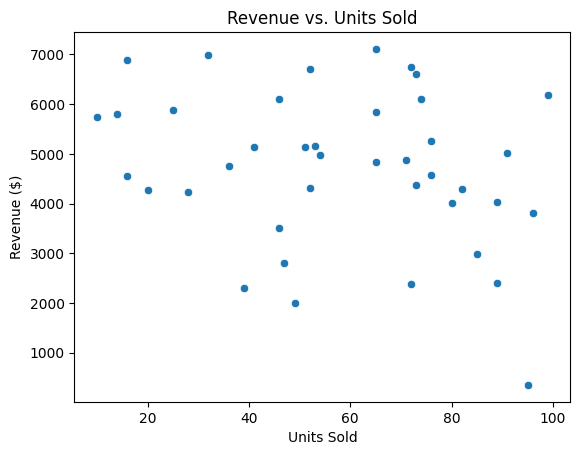

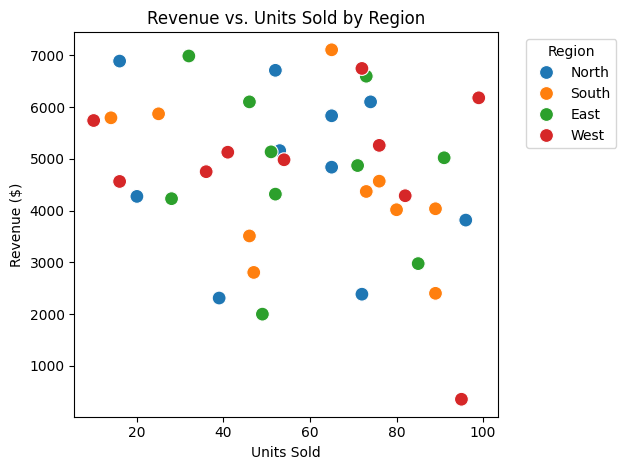

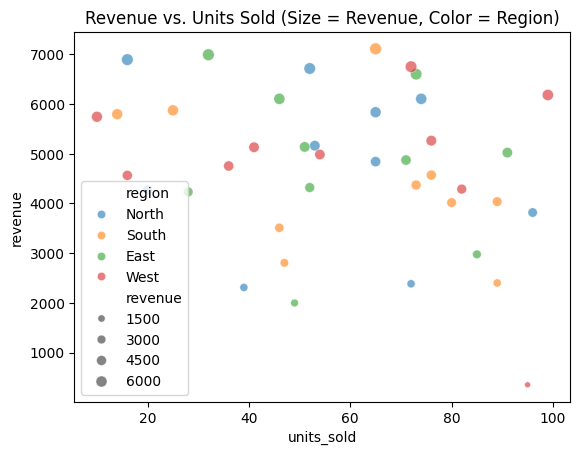

In [3]:
# Basic scatter plot: Revenue vs. Units Sold
sns.scatterplot(data=sales, x='units_sold', y='revenue')
plt.title('Revenue vs. Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Revenue ($)')
plt.show()

# Scatter plot with hue: Add region as a color dimension
sns.scatterplot(data=sales, x='units_sold', y='revenue', hue='region', s=100)
plt.title('Revenue vs. Units Sold by Region')
plt.xlabel('Units Sold')
plt.ylabel('Revenue ($)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatter plot with multiple dimensions
sns.scatterplot(data=sales, x='units_sold', y='revenue',
                hue='region', size='revenue', alpha=0.6)
plt.title('Revenue vs. Units Sold (Size = Revenue, Color = Region)')
plt.show()

**When to use scatter plots:**
- Identifying correlations between two numeric variables
- Detecting outliers or unusual patterns
- Comparing groups using `hue`
- Exploring non-linear relationships

---

## Box Plots: Understanding Data Distribution and Outliers

Box plots display data distribution across quartiles and highlight outliers. Key components:

- **Box**: Contains the middle 50% of data (25th to 75th percentile)
- **Line inside box**: The median (50th percentile)
- **Whiskers**: Extend to 1.5× the interquartile range (IQR)
- **Points beyond whiskers**: Outliers (unusual values worth investigating)

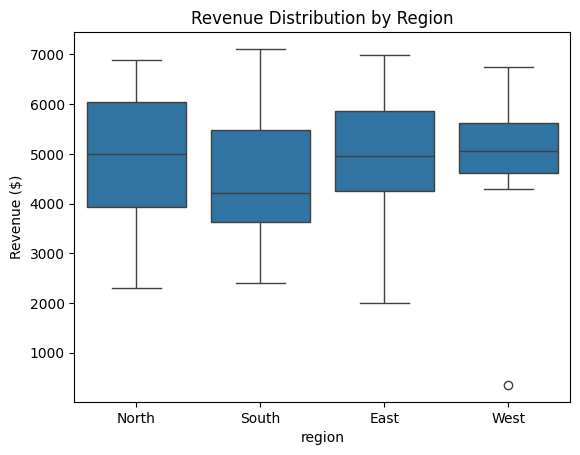

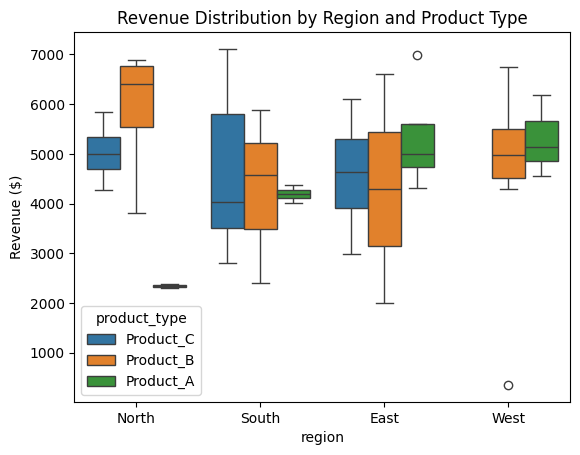

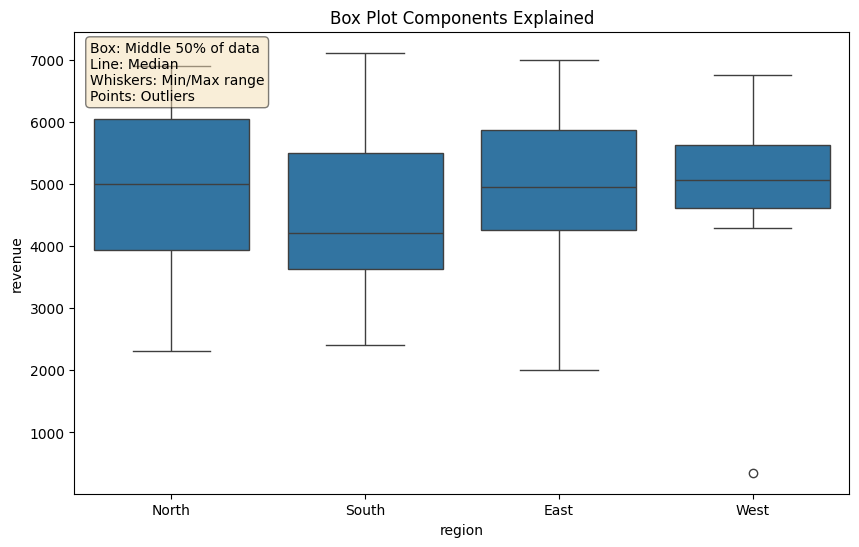

In [4]:
# Basic box plot: Revenue distribution by region
sns.boxplot(data=sales, x='region', y='revenue')
plt.title('Revenue Distribution by Region')
plt.ylabel('Revenue ($)')
plt.show()

# Box plot with hue: Add product type as a second categorical dimension
sns.boxplot(data=sales, x='region', y='revenue', hue='product_type')
plt.title('Revenue Distribution by Region and Product Type')
plt.ylabel('Revenue ($)')
plt.show()

# Annotated box plot explaining components
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=sales, x='region', y='revenue', ax=ax)

# Add annotations
ax.text(0.02, 0.98,
        'Box: Middle 50% of data\nLine: Median\nWhiskers: Min/Max range\nPoints: Outliers',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.title('Box Plot Components Explained')
plt.show()

**When to use box plots:**
- Comparing distributions across groups
- Identifying outliers in your data
- Understanding data spread and skewness
- Detecting data quality issues

---

## Line Plots: Tracking Changes Over Time

Line plots are ideal for time series data, showing how values change over time. Use `hue` to track multiple series simultaneously.

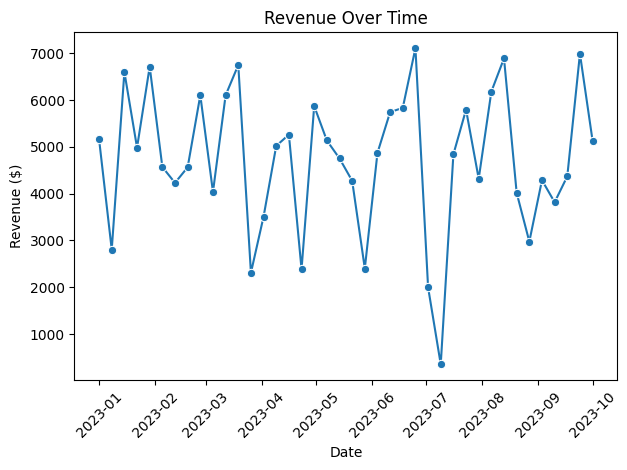

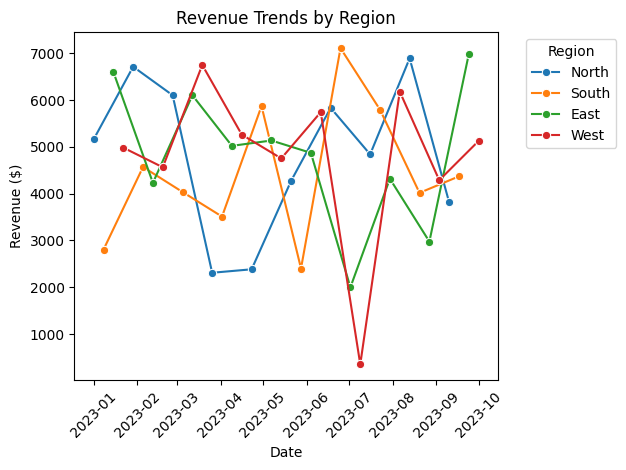

In [5]:
# Basic line plot: Revenue over time
sns.lineplot(data=sales, x='date', y='revenue', marker='o')
plt.title('Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Line plot with hue: Track revenue by region over time
sns.lineplot(data=sales, x='date', y='revenue', hue='region', marker='o')
plt.title('Revenue Trends by Region')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**When to use line plots:**
- Showing trends over time
- Comparing multiple time series
- Identifying seasonal patterns
- Tracking cumulative changes

---

## Distribution Plots: Visualizing Data Frequency

Distribution plots (histograms with optional KDE curves) show how values are distributed across a range.

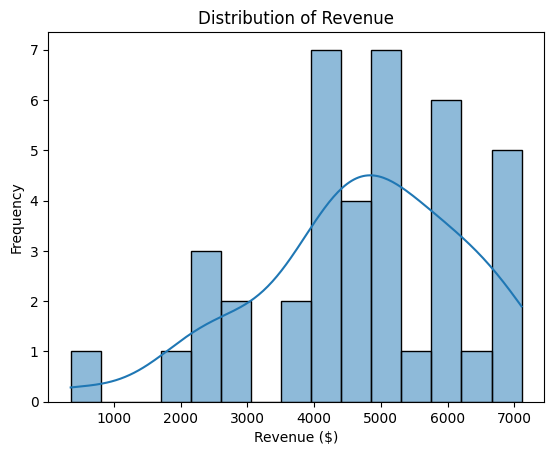

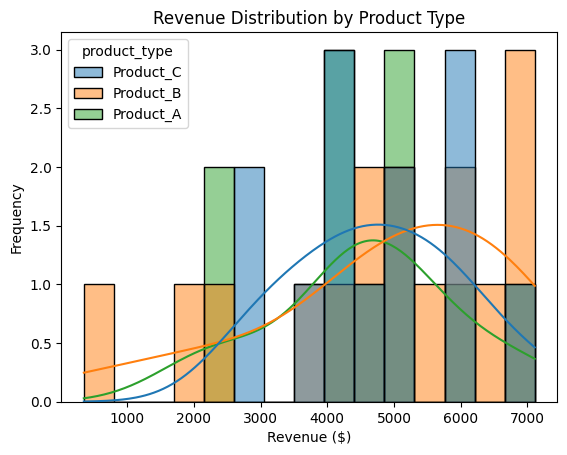

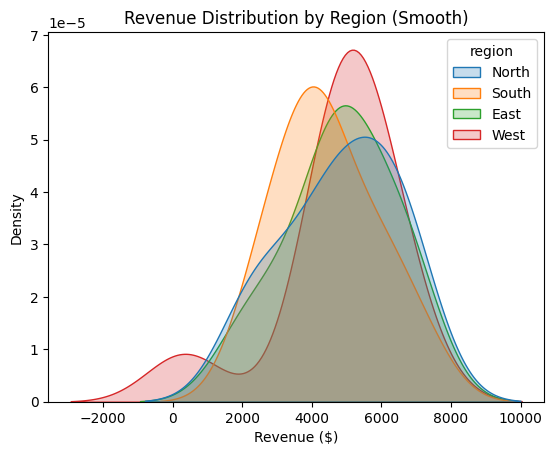

In [6]:
# Histogram: Distribution of revenue
sns.histplot(data=sales, x='revenue', kde=True, bins=15)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency')
plt.show()

# Histogram with hue: Compare distributions by product type
sns.histplot(data=sales, x='revenue', hue='product_type', kde=True, bins=15)
plt.title('Revenue Distribution by Product Type')
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency')
plt.show()

# KDE plot (smooth distribution curve)
sns.kdeplot(data=sales, x='revenue', hue='region', fill=True)
plt.title('Revenue Distribution by Region (Smooth)')
plt.xlabel('Revenue ($)')
plt.show()

**When to use distribution plots:**
- Understanding data shape and spread
- Checking for normality (bell curve)
- Identifying skewness or multimodal distributions
- Comparing distributions across groups

---

## Count Plots: Visualizing Categorical Data

Count plots show the frequency of each category, useful for categorical data analysis.

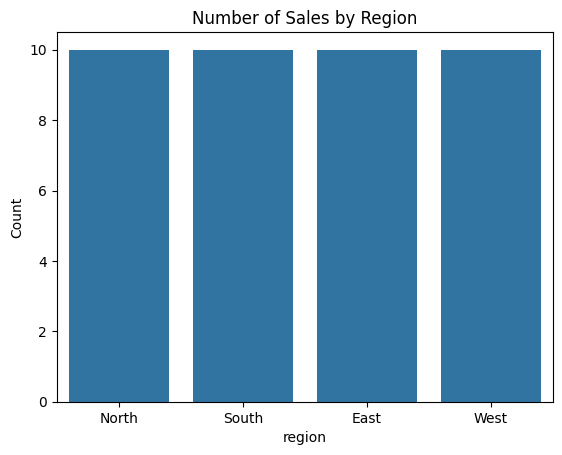

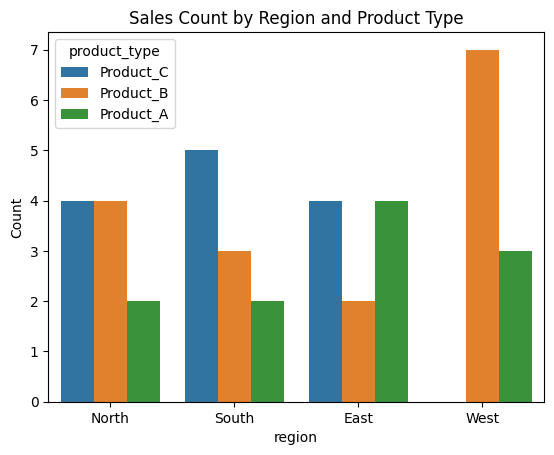

In [7]:
# Basic count plot: Sales count by region
sns.countplot(data=sales, x='region')
plt.title('Number of Sales by Region')
plt.ylabel('Count')
plt.show()

# Count plot with hue: Break down by product type
sns.countplot(data=sales, x='region', hue='product_type')
plt.title('Sales Count by Region and Product Type')
plt.ylabel('Count')
plt.show()

**When to use count plots:**
- Showing frequency of categorical variables
- Comparing group sizes
- Identifying imbalanced categories
- Breaking down categories by subcategories

---

## Heatmaps: Visualizing Correlations and Pivot Tables

Heatmaps use color intensity to represent numeric values. In correlation heatmaps, colors represent the strength of relationships between variables.

**Understanding correlation values:**
- **1.0**: Perfect positive correlation (both increase together)
- **0.0**: No correlation (no relationship)
- **-1.0**: Perfect negative correlation (one increases as the other decreases)
- **Color scale**: "coolwarm" uses cool colors (blue) for negative correlations and warm colors (red) for positive correlations

Correlation Matrix:
            units_sold   revenue
units_sold    1.000000 -0.260626
revenue      -0.260626  1.000000


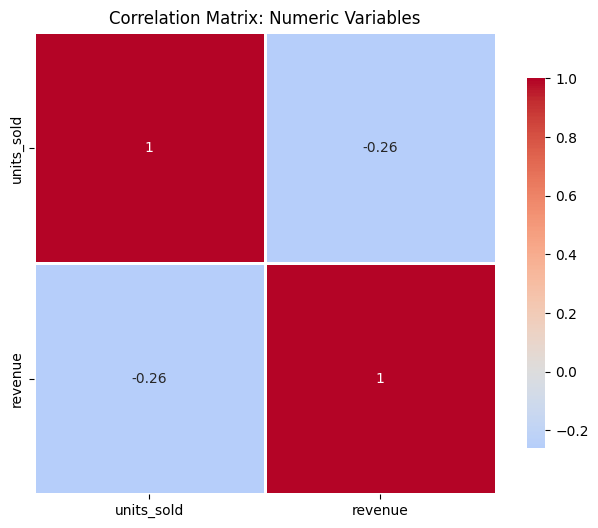

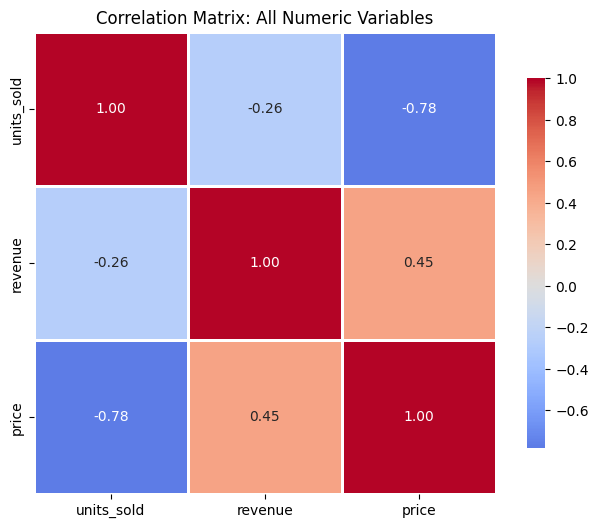

In [8]:
# Prepare numeric data only
numeric_sales = sales[['units_sold', 'revenue']].copy()

# Calculate correlation matrix
corr = numeric_sales.corr()
print("Correlation Matrix:")
print(corr)

# Create correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Numeric Variables')
plt.show()

# Heatmap with additional variables
sales['price'] = sales['revenue'] / sales['units_sold']
numeric_sales = sales[['units_sold', 'revenue', 'price']].copy()

corr = numeric_sales.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: All Numeric Variables')
plt.show()

**Understanding `annot=True`**: When `annot=True`, correlation values appear in each cell, making exact coefficients easy to read.

**When to use heatmaps:**
- Exploring correlations between numeric variables
- Visualizing pivot tables
- Identifying multicollinearity in datasets
- Displaying large matrices of data

---

## Violin Plots: Distribution Shape with Statistical Summary

Violin plots combine box plot information with distribution shape, showing the full distribution while maintaining summary statistics.

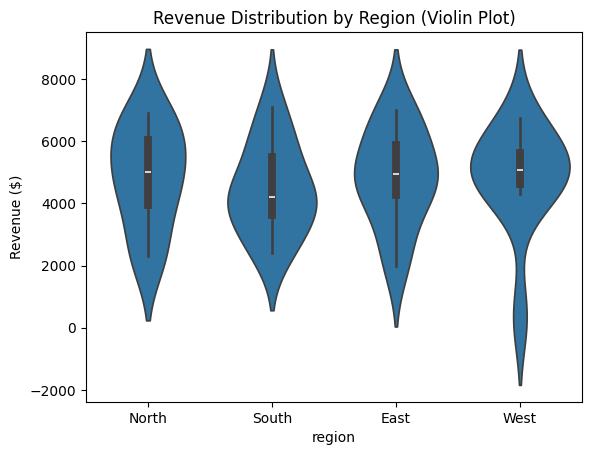

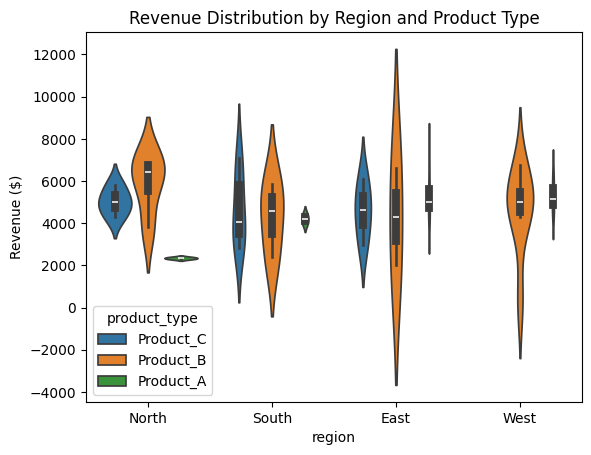

In [9]:
# Violin plot: Revenue distribution by region
sns.violinplot(data=sales, x='region', y='revenue')
plt.title('Revenue Distribution by Region (Violin Plot)')
plt.ylabel('Revenue ($)')
plt.show()

# Violin plot with hue: Add product type dimension
sns.violinplot(data=sales, x='region', y='revenue', hue='product_type')
plt.title('Revenue Distribution by Region and Product Type')
plt.ylabel('Revenue ($)')
plt.show()

**When to use violin plots:**
- Showing full distribution shape (better than box plots for complex distributions)
- Comparing distributions across groups
- Identifying bimodal or multimodal distributions
- Presenting publication-quality visualizations

---

## Pair Plots: Exploring Multivariate Relationships

Pair plots create a matrix of scatter plots showing relationships between all numeric variables, with distributions on the diagonal.

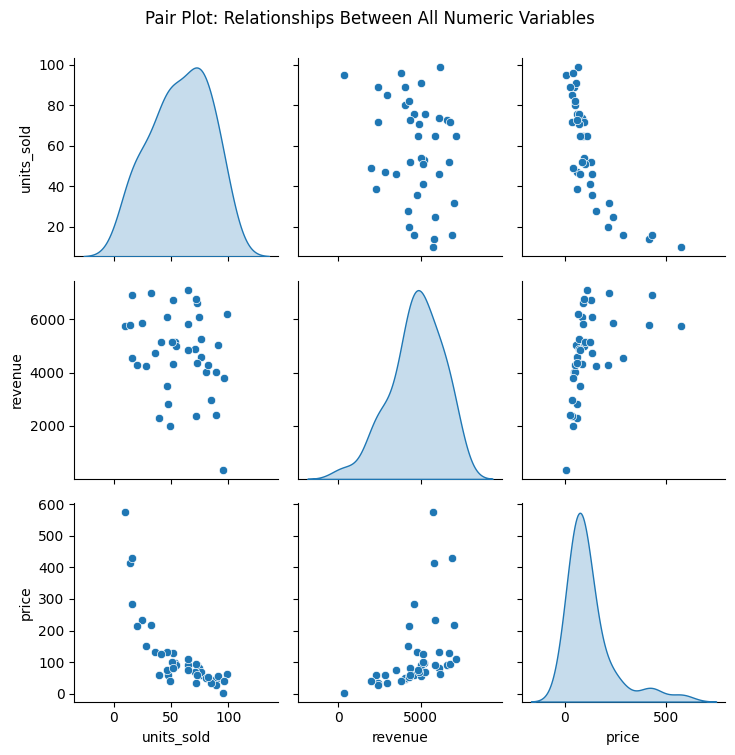

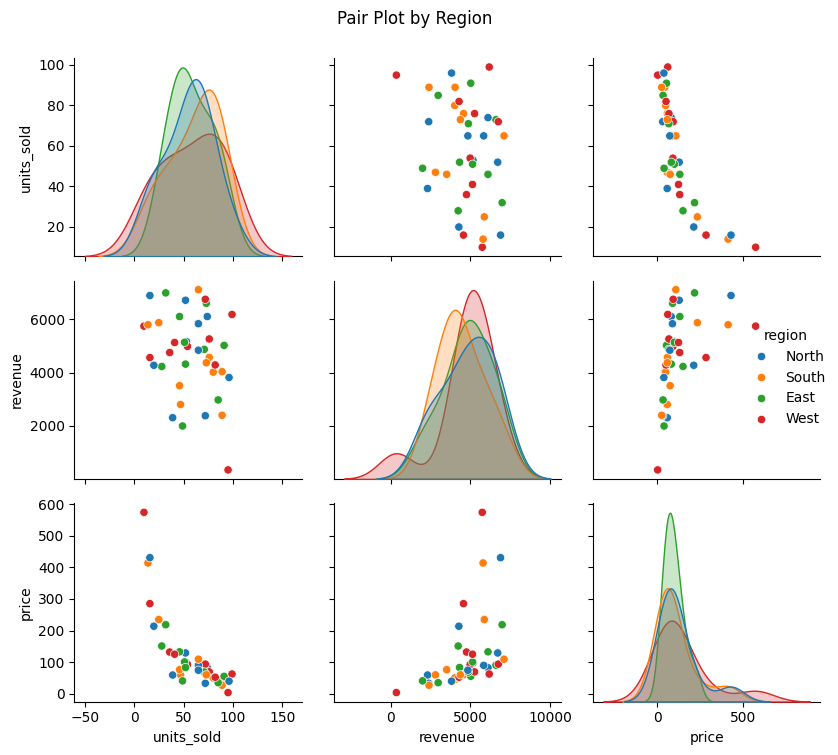

In [10]:
# The 'price' column was added earlier in the heatmap section
# Create pair plot for numeric variables
numeric_cols = ['units_sold', 'revenue', 'price']
sns.pairplot(sales[numeric_cols], diag_kind='kde')
plt.suptitle('Pair Plot: Relationships Between All Numeric Variables', y=1.00)
plt.tight_layout()
plt.show()

# Pair plot with hue to color by category
sns.pairplot(sales[numeric_cols + ['region']], hue='region', diag_kind='kde')
plt.suptitle('Pair Plot by Region', y=1.00)
plt.tight_layout()
plt.show()

**When to use pair plots:**
- Exploring relationships in multivariate datasets
- Identifying patterns across multiple variables simultaneously
- Conducting initial exploratory data analysis (EDA)
- Detecting correlations and outliers

---

## Customization Basics: Controlling Appearance

Control figure size, colors, labels, and other aesthetics:

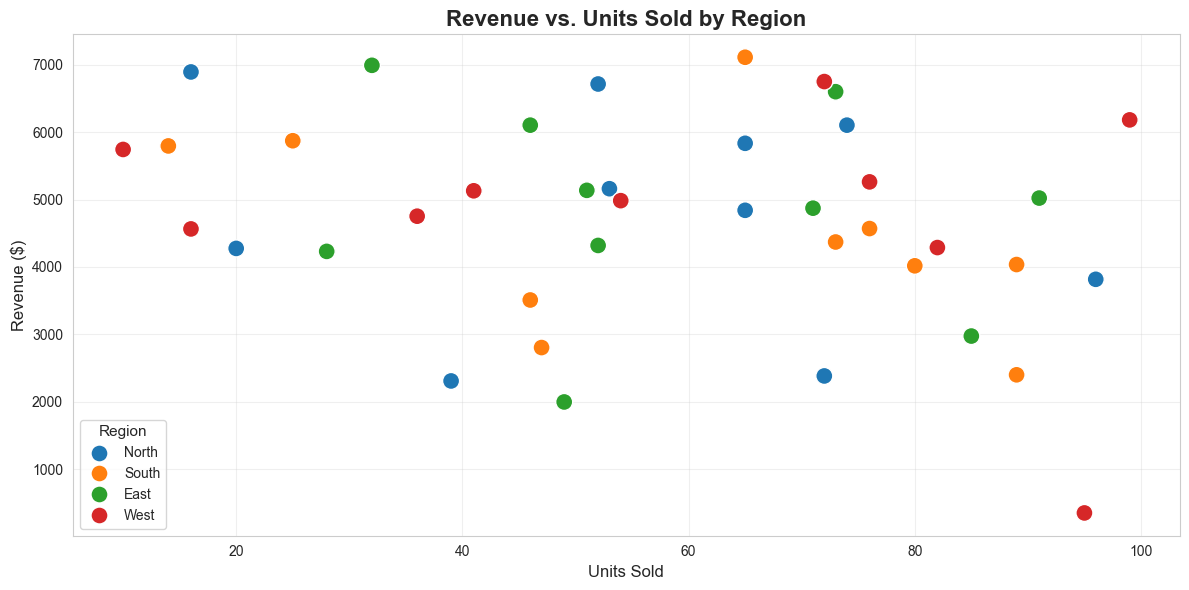

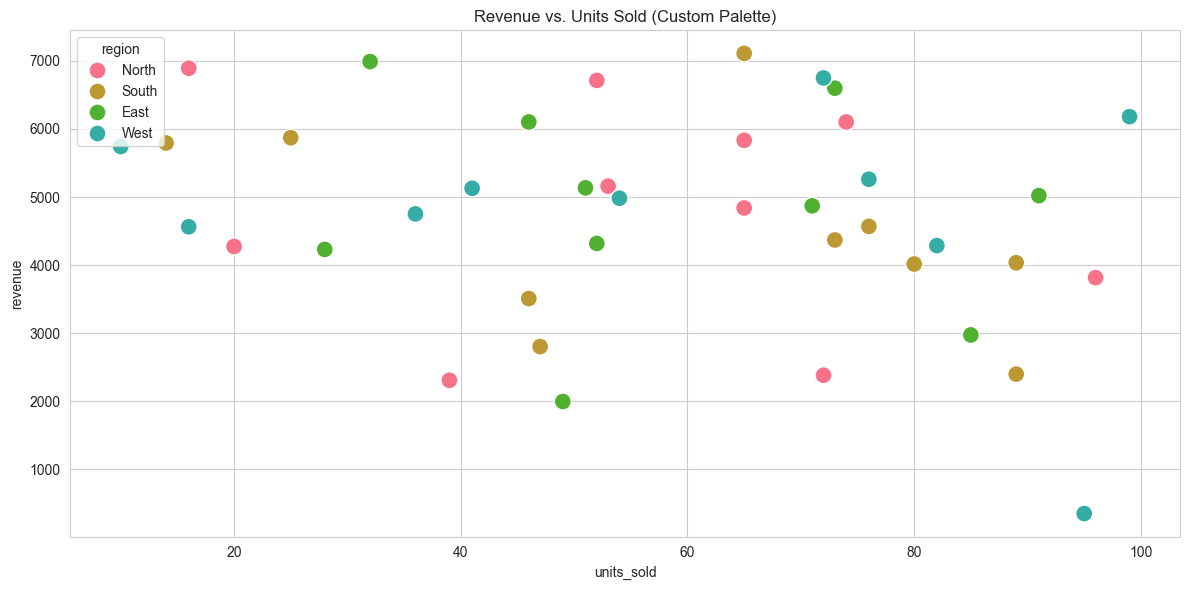

In [11]:
# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create plot with customization
sns.scatterplot(data=sales, x='units_sold', y='revenue', hue='region', s=150)

# Customize labels and title
plt.title('Revenue vs. Units Sold by Region', fontsize=16, fontweight='bold')
plt.xlabel('Units Sold', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(title='Region', fontsize=10, title_fontsize=11)

# Add grid and adjust layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Change color palette
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
sns.scatterplot(data=sales, x='units_sold', y='revenue', hue='region', s=150)
plt.title('Revenue vs. Units Sold (Custom Palette)')
plt.tight_layout()
plt.show()

---

## Common Pitfalls and Solutions

| Problem | Solution |
|---------|----------|
| `.corr()` fails with "no numeric types to aggregate" | Use `.select_dtypes(include=[np.number])` to select only numeric columns |
| Heatmap is unreadable with too many variables | Subset to most important variables or adjust colorbar with `cbar_kws` |
| Legend overlaps the plot | Use `bbox_to_anchor=(1.05, 1)` and `plt.tight_layout()` |
| Date labels are crowded | Use `plt.xticks(rotation=45)` and `plt.tight_layout()` |
| Scatter plot points overlap (overplotting) | Use `alpha=0.5` for transparency or reduce size with `s=50` |
| Non-numeric columns cause errors in `.corr()` | Filter to numeric columns: `sales.select_dtypes(include=[np.number]).corr()` |

---

## Real-World Example: Complete Analysis Workflow

Dataset shape: (40, 6)

Data types:
region                  object
units_sold               int64
revenue                float64
product_type            object
date            datetime64[ns]
price                  float64
dtype: object

Basic statistics:
       units_sold      revenue                 date       price
count   40.000000    40.000000                   40   40.000000
mean    56.950000  5165.156674  2023-05-17 12:00:00  126.417198
min     10.000000  1797.854454  2023-01-01 00:00:00   23.971393
25%     42.500000  3954.266383  2023-03-10 06:00:00   60.122210
50%     55.000000  4991.709770  2023-05-17 12:00:00   90.307794
75%     75.750000  6401.225482  2023-07-24 18:00:00  144.793515
max     99.000000  8484.453756  2023-10-01 00:00:00  565.630250
std     24.691896  1778.661911                  NaN  112.354710

Missing values:
region          0
units_sold      0
revenue         0
product_type    0
date            0
price           0
dtype: int64


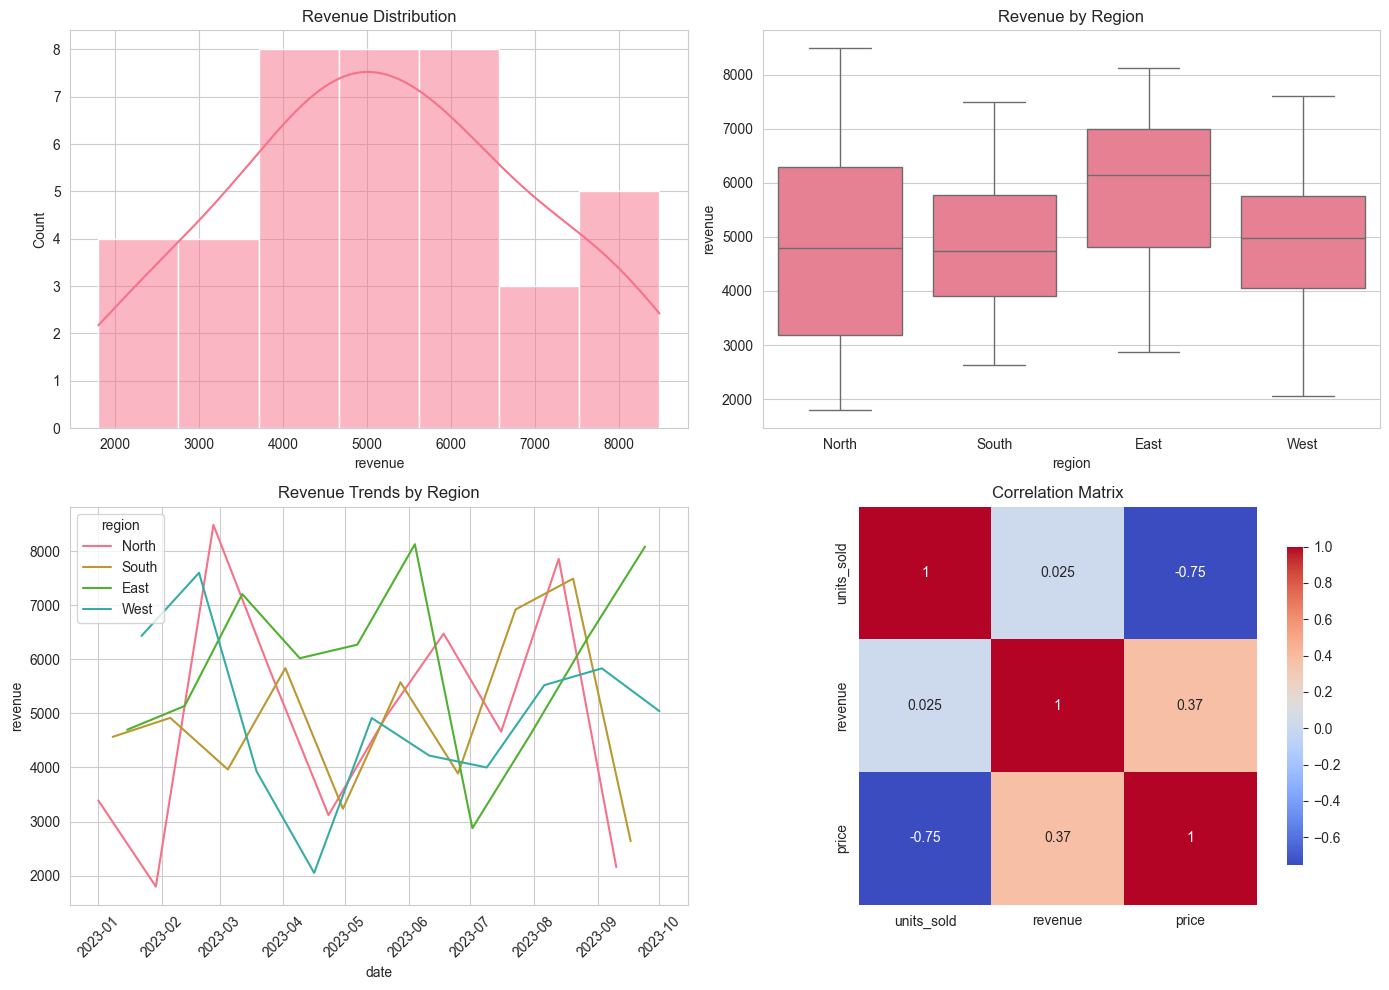


Key Insights:
Average revenue: $5165.16
Revenue by region:
region
East     5940.360284
North    4863.183074
South    4903.241627
West     4953.841713
Name: revenue, dtype: float64

Correlation between units_sold and revenue: 0.025


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Recreate the sales DataFrame with the 'price' column included
sales = pd.DataFrame({
    'region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West'] * 5,
    'units_sold': np.random.randint(10, 100, 40),
    'revenue': np.random.normal(5000, 1500, 40),
    'product_type': np.random.choice(['Product_A', 'Product_B', 'Product_C'], 40),
    'date': pd.date_range('2023-01-01', periods=40, freq='W')
})
sales['price'] = sales['revenue'] / sales['units_sold']

# Step 1: Explore data
print("Dataset shape:", sales.shape)
print("\nData types:")
print(sales.dtypes)
print("\nBasic statistics:")
print(sales.describe())

# Step 2: Check for data quality issues
print("\nMissing values:")
print(sales.isnull().sum())

# Step 3: Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Distribution of revenue
sns.histplot(data=sales, x='revenue', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Revenue Distribution')

# Subplot 2: Revenue by region
sns.boxplot(data=sales, x='region', y='revenue', ax=axes[0, 1])
axes[0, 1].set_title('Revenue by Region')

# Subplot 3: Revenue over time by region
sns.lineplot(data=sales, x='date', y='revenue', hue='region', ax=axes[1, 0])
axes[1, 0].set_title('Revenue Trends by Region')
axes[1, 0].tick_params(axis='x', rotation=45)

# Subplot 4: Correlation heatmap
numeric_sales = sales[['units_sold', 'revenue', 'price']].corr()
sns.heatmap(numeric_sales, annot=True, cmap='coolwarm', ax=axes[1, 1],
            square=True, cbar_kws={"shrink": 0.8})
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Step 4: Extract insights
print("\nKey Insights:")
print(f"Average revenue: ${sales['revenue'].mean():.2f}")
print(f"Revenue by region:\n{sales.groupby('region')['revenue'].mean()}")
print(f"\nCorrelation between units_sold and revenue: {sales['units_sold'].corr(sales['revenue']):.3f}")

---

## Decision Guide: Choosing the Right Plot

| Question | Plot Type |
|----------|-----------|
| Showing relationship between 2 numeric variables? | Scatter Plot |
| Comparing distributions across groups? | Box Plot or Violin Plot |
| Tracking changes over time? | Line Plot |
| Showing frequency of categories? | Count Plot |
| Visualizing correlations between variables? | Heatmap |
| Exploring multivariate relationships? | Pair Plot |
| Showing data frequency/shape? | Histogram or KDE |

---

## Summary

Seaborn and pandas together enable efficient creation of publication-quality visualizations. Start with simple plots, gradually add dimensions using `hue` and other parameters, and customize appearance to match your needs. This combination makes exploratory data analysis intuitive and professional.

---

# Basic Plotting with Pandas

Pandas makes it easy to create quick, informative plots directly from your DataFrames and Series. These are perfect for initial data exploration and sharing insights. The `.plot()` method wraps Matplotlib, letting you visualize data without writing complex plotting code.

## When to Use Pandas Plotting

Pandas plotting is ideal when you want to:
- **Quickly explore data** without setting up complex Matplotlib code
- **Create static visualizations** for reports and presentations
- **Compare multiple columns** in a single command
- **Work interactively** in Jupyter notebooks

For advanced customization or interactive dashboards, consider using Matplotlib directly or libraries like Plotly.

---

## Plot Type Guide: Choosing the Right Visualization

| Your Question | Plot Type | Use Case |
|---|---|---|
| How does this metric change **over time**? | Line Plot | Stock prices, temperature trends, website traffic |
| How do **categories compare** to each other? | Bar Plot | Sales by region, product performance, survey responses |
| What's the **distribution** of my data? | Histogram | Customer ages, test scores, revenue amounts |
| Is there a **relationship** between two variables? | Scatter Plot | Height vs. weight, ad spend vs. revenue, temperature vs. ice cream sales |
| What are the **outliers and spread** in my data? | Box Plot | Salary ranges by department, performance across quarters |
| What **proportions** make up the whole? | Pie Chart | Market share, budget allocation, revenue by region |

---

## Line Plots: Visualizing Trends Over Time

**What it does:** A line plot connects data points in order, making it easy to see trends, patterns, and changes over time.

**When to use:** Time series data, tracking metrics over days/months/years, comparing multiple trends.

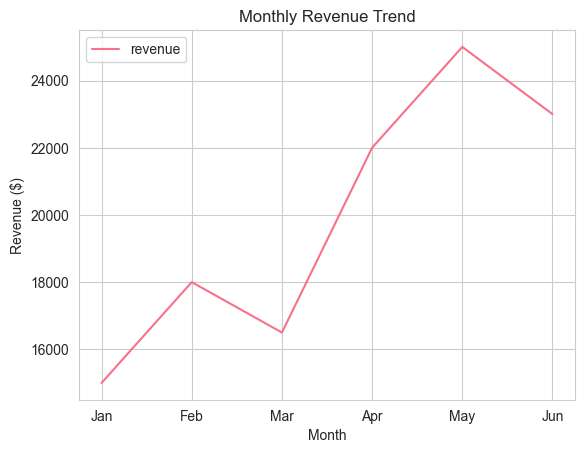

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Create sample sales data
sales = pd.DataFrame({
    'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'revenue': [15000, 18000, 16500, 22000, 25000, 23000],
    'expenses': [8000, 9000, 8500, 10000, 11000, 10500]
})

# Basic line plot
sales.plot(x='month', y='revenue', kind='line', title='Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.show()

**What's happening:**
- `x='month'`: Use the 'month' column for the horizontal axis
- `y='revenue'`: Plot the 'revenue' column on the vertical axis
- `kind='line'`: Create a line plot (connects points with lines)

### Customizing Line Plots

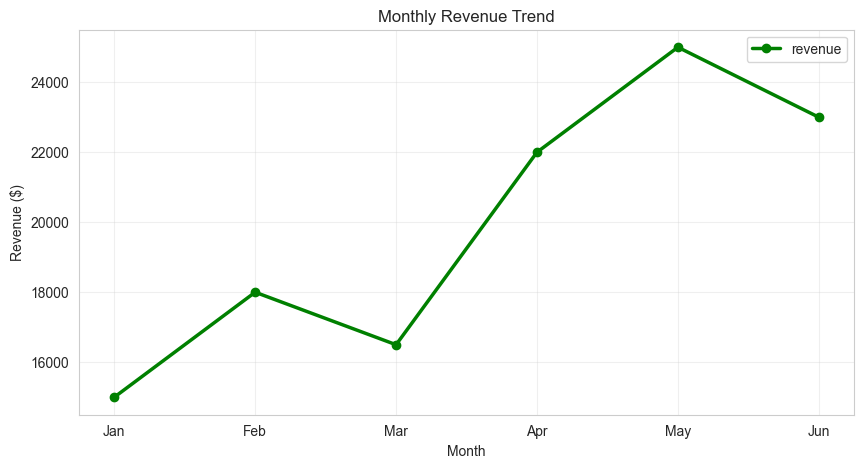

In [14]:
# Larger figure, custom colors, thicker lines
sales.plot(
    x='month',
    y='revenue',
    kind='line',
    title='Monthly Revenue Trend',
    figsize=(10, 5),           # Width=10 inches, Height=5 inches
    color='green',             # Line color
    linewidth=2.5,             # Thicker line
    marker='o'                 # Add circle markers at each point
)
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)      # Add subtle gridlines
plt.show()

### Plotting Multiple Lines

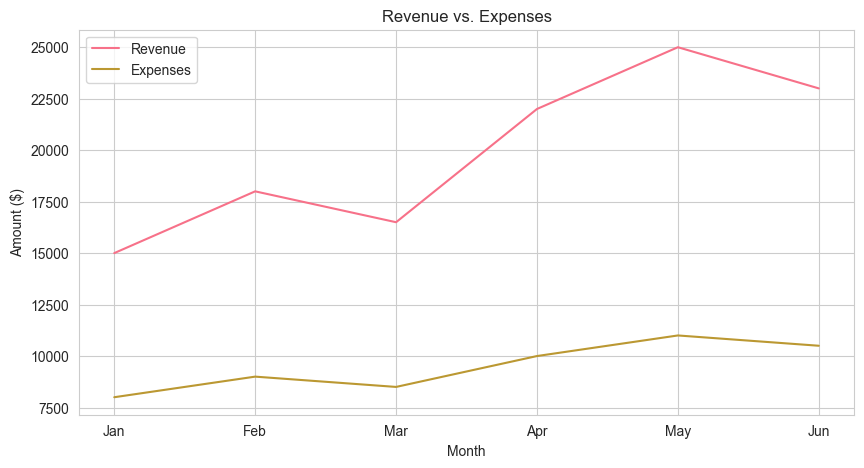

In [15]:
# Plot both revenue and expenses on the same chart
sales.plot(
    x='month',
    y=['revenue', 'expenses'],  # List of columns to plot
    kind='line',
    title='Revenue vs. Expenses',
    figsize=(10, 5)
)
plt.ylabel('Amount ($)')
plt.xlabel('Month')
plt.legend(['Revenue', 'Expenses'])  # Label each line
plt.show()

---

## Bar Plots: Comparing Categories

**What it does:** A bar plot uses rectangular bars to compare values across categories. The height of each bar represents the value.

**When to use:** Comparing sales by region, product performance, survey responses, or any categorical comparison.

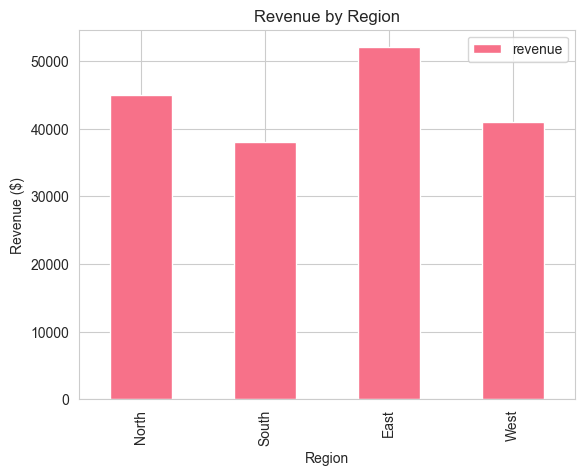

In [16]:
# Create sample data by region
sales_by_region = pd.DataFrame({
    'region': ['North', 'South', 'East', 'West'],
    'revenue': [45000, 38000, 52000, 41000]
})

# Basic bar plot
sales_by_region.plot(x='region', y='revenue', kind='bar', title='Revenue by Region')
plt.ylabel('Revenue ($)')
plt.xlabel('Region')
plt.show()

### Using GroupBy with Bar Plots

GroupBy aggregates data before plotting, making it easy to compare groups:

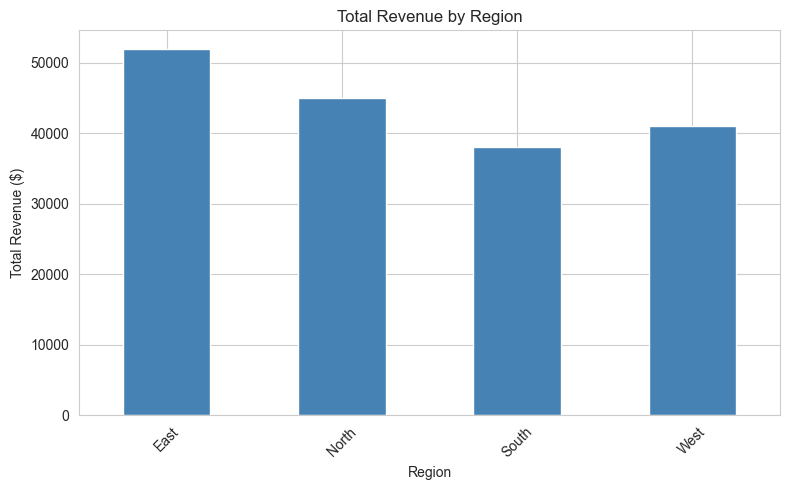

In [17]:
# Create more detailed sales data
sales_detail = pd.DataFrame({
    'region': ['North', 'North', 'South', 'South', 'East', 'East', 'West', 'West'],
    'product': ['A', 'B', 'A', 'B', 'A', 'B', 'A', 'B'],
    'revenue': [25000, 20000, 18000, 20000, 30000, 22000, 20000, 21000]
})

# Group by region and sum revenue, then plot
sales_detail.groupby('region')['revenue'].sum().plot(
    kind='bar',
    title='Total Revenue by Region',
    figsize=(8, 5),
    color='steelblue'
)
plt.ylabel('Total Revenue ($)')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Horizontal Bar Plots (Better for Long Labels)

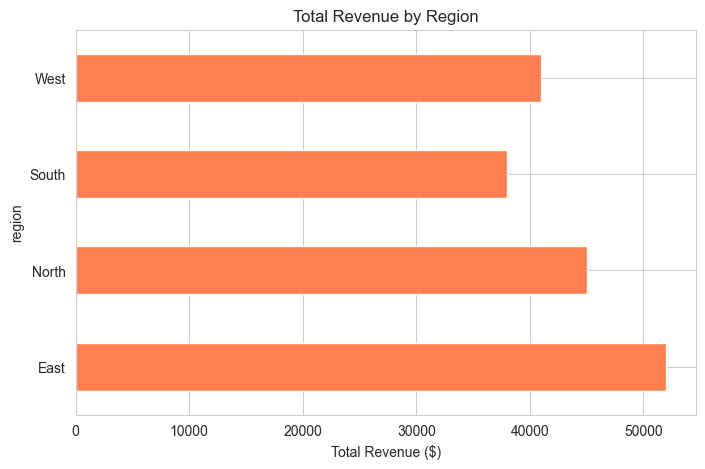

In [18]:
# Horizontal bars are easier to read with long category names
sales_detail.groupby('region')['revenue'].sum().plot(
    kind='barh',  # 'barh' = horizontal bar
    title='Total Revenue by Region',
    figsize=(8, 5),
    color='coral'
)
plt.xlabel('Total Revenue ($)')
plt.show()

---

## Histograms: Understanding Data Distribution

**What it does:** A histogram divides your data into equal-width "buckets" (called bins) and shows how many values fall into each bucket. This reveals the shape and spread of your data.

**When to use:** Understanding data distribution, identifying outliers, checking for normal distribution, analyzing frequency patterns.

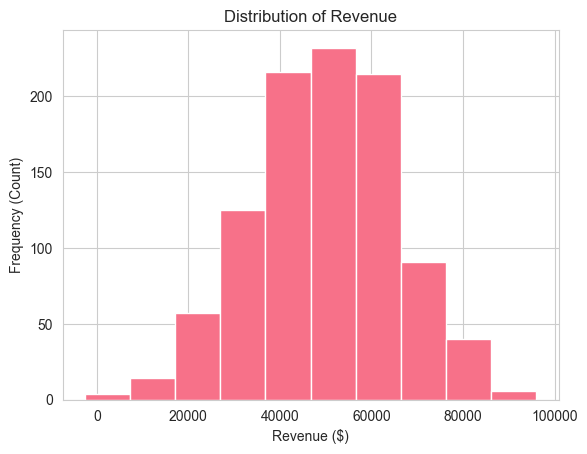

In [19]:
import numpy as np

# Create sample revenue data
revenue_data = pd.DataFrame({
    'revenue': np.random.normal(loc=50000, scale=15000, size=1000)
})

# Basic histogram
revenue_data['revenue'].plot(kind='hist', title='Distribution of Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency (Count)')
plt.show()

### Understanding the `bins` Parameter

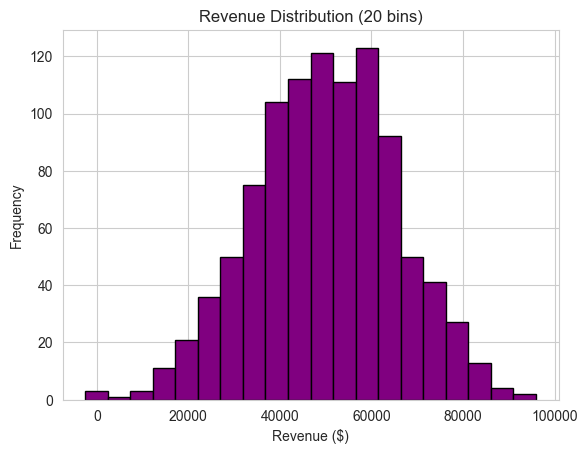

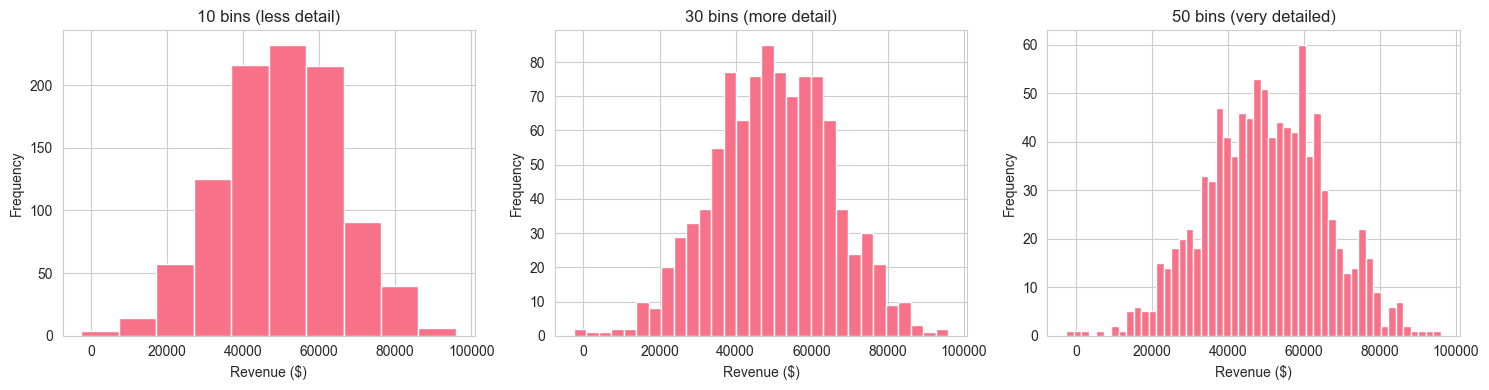

In [20]:
# bins=20 divides data into 20 equal-width buckets
revenue_data['revenue'].plot(
    kind='hist',
    bins=20,  # More bins = more detail (but can be noisy)
    title='Revenue Distribution (20 bins)',
    color='purple',
    edgecolor='black'  # Add border around bars
)
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency')
plt.show()

# Compare different bin sizes to find the right level of detail
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

revenue_data['revenue'].plot(kind='hist', bins=10, ax=axes[0], title='10 bins (less detail)')
revenue_data['revenue'].plot(kind='hist', bins=30, ax=axes[1], title='30 bins (more detail)')
revenue_data['revenue'].plot(kind='hist', bins=50, ax=axes[2], title='50 bins (very detailed)')

for ax in axes:
    ax.set_xlabel('Revenue ($)')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

---

## Scatter Plots: Finding Relationships Between Variables

**What it does:** A scatter plot shows individual data points as dots, revealing whether two variables are related (correlated).

**When to use:** Finding relationships between variables, identifying outliers, checking for patterns or clusters.

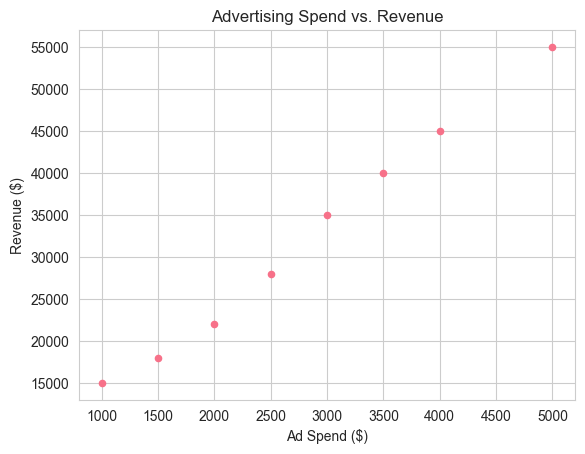

In [21]:
# Create sample data: advertising spend vs. revenue
marketing = pd.DataFrame({
    'ad_spend': [1000, 2000, 1500, 3000, 2500, 4000, 3500, 5000],
    'revenue': [15000, 22000, 18000, 35000, 28000, 45000, 40000, 55000]
})

# Basic scatter plot
marketing.plot(
    x='ad_spend',
    y='revenue',
    kind='scatter',
    title='Advertising Spend vs. Revenue'
)
plt.xlabel('Ad Spend ($)')
plt.ylabel('Revenue ($)')
plt.show()

### Customizing Scatter Plots

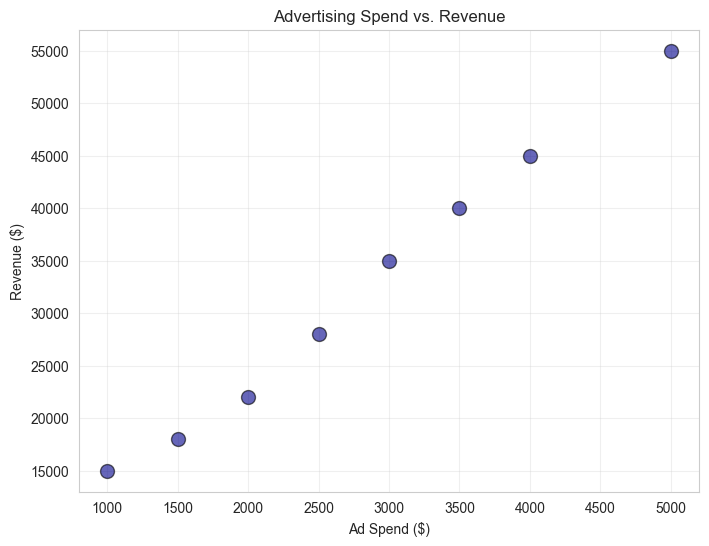

In [22]:
# Larger points, custom colors, transparency
marketing.plot(
    x='ad_spend',
    y='revenue',
    kind='scatter',
    title='Advertising Spend vs. Revenue',
    figsize=(8, 6),
    s=100,              # Size of points (default is 30)
    color='darkblue',
    alpha=0.6,          # Transparency (0=invisible, 1=opaque)
    edgecolors='black'  # Border around points
)
plt.xlabel('Ad Spend ($)')
plt.ylabel('Revenue ($)')
plt.grid(True, alpha=0.3)
plt.show()

---

## Box Plots: Visualizing Distribution, Outliers, and Spread

**What it does:** A box plot shows the median, quartiles (25th and 75th percentiles), and outliers in your data. The "box" contains the middle 50% of data, and "whiskers" extend to show the range.

**When to use:** Comparing distributions across groups, identifying outliers, understanding data spread and symmetry.

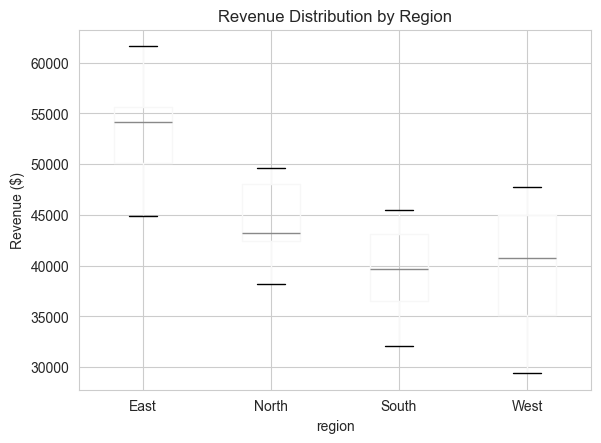

In [23]:
# Create sample data: revenue by region
sales_by_region_detail = pd.DataFrame({
    'region': ['North']*10 + ['South']*10 + ['East']*10 + ['West']*10,
    'revenue': np.concatenate([
        np.random.normal(45000, 5000, 10),  # North: mean 45k, std 5k
        np.random.normal(38000, 6000, 10),  # South: mean 38k, std 6k
        np.random.normal(52000, 4000, 10),  # East: mean 52k, std 4k
        np.random.normal(41000, 7000, 10)   # West: mean 41k, std 7k
    ])
})

# Basic box plot
sales_by_region_detail.boxplot(column='revenue', by='region')
plt.ylabel('Revenue ($)')
plt.suptitle('')  # Remove automatic title
plt.title('Revenue Distribution by Region')
plt.show()

### Understanding Box Plot Components

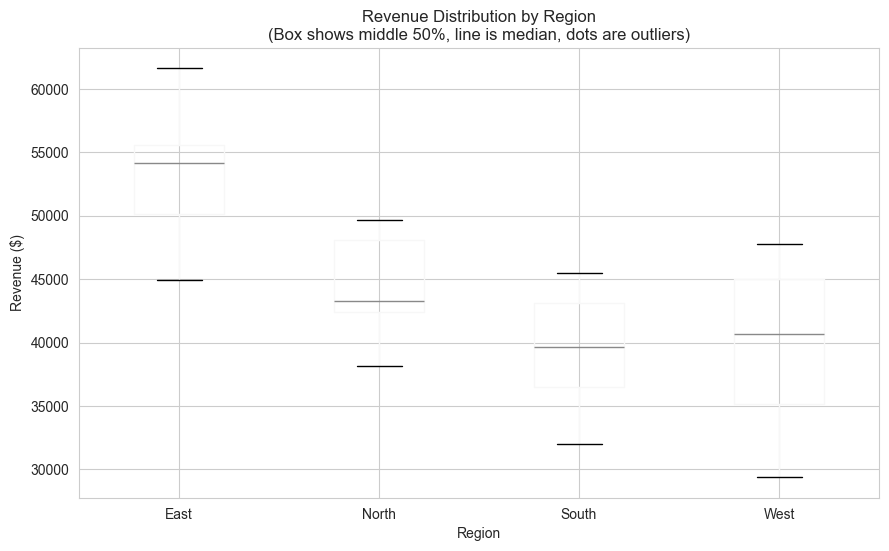

        count          mean          std           min           25%  \
region                                                                 
East     10.0  53632.405771  5184.121452  44931.399942  50147.483711   
North    10.0  44619.463376  3718.262002  38190.767030  42441.919513   
South    10.0  39415.518399  4650.685268  32032.475780  36464.597368   
West     10.0  39863.915890  6184.880558  29382.897027  35155.947766   

                 50%           75%           max  
region                                            
East    54132.748472  55609.427174  61628.314858  
North   43257.725151  48082.692989  49665.285114  
South   39669.032257  43126.902398  45460.904798  
West    40700.538507  44999.274362  47762.576501  


In [24]:
# Create cleaner box plot with explanatory labels
fig, ax = plt.subplots(figsize=(10, 6))
sales_by_region_detail.boxplot(column='revenue', by='region', ax=ax)
plt.ylabel('Revenue ($)')
plt.xlabel('Region')
plt.suptitle('')
plt.title('Revenue Distribution by Region\n(Box shows middle 50%, line is median, dots are outliers)')
plt.show()

# Print statistics to understand the plot
print(sales_by_region_detail.groupby('region')['revenue'].describe())

---

## Pie Charts: Showing Proportions and Composition

**What it does:** A pie chart divides a circle into slices, where each slice's size represents a proportion of the whole.

**When to use:** Showing market share, budget allocation, revenue breakdown by category, composition of a total.

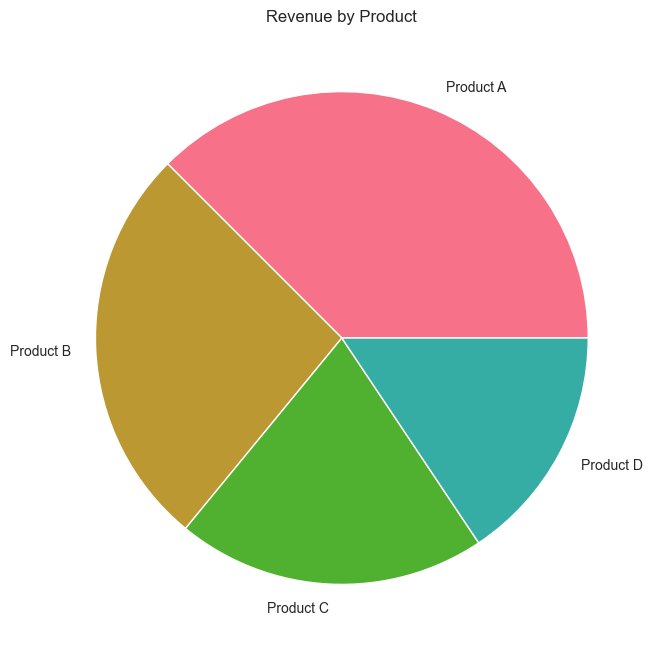

In [25]:
# Create sample data: revenue by product
revenue_by_product = pd.DataFrame({
    'product': ['Product A', 'Product B', 'Product C', 'Product D'],
    'revenue': [120000, 85000, 65000, 50000]
})

# Basic pie chart
revenue_by_product.set_index('product')['revenue'].plot(
    kind='pie',
    title='Revenue by Product',
    figsize=(8, 8)
)
plt.ylabel('')  # Remove automatic label
plt.show()

### Customizing Pie Charts

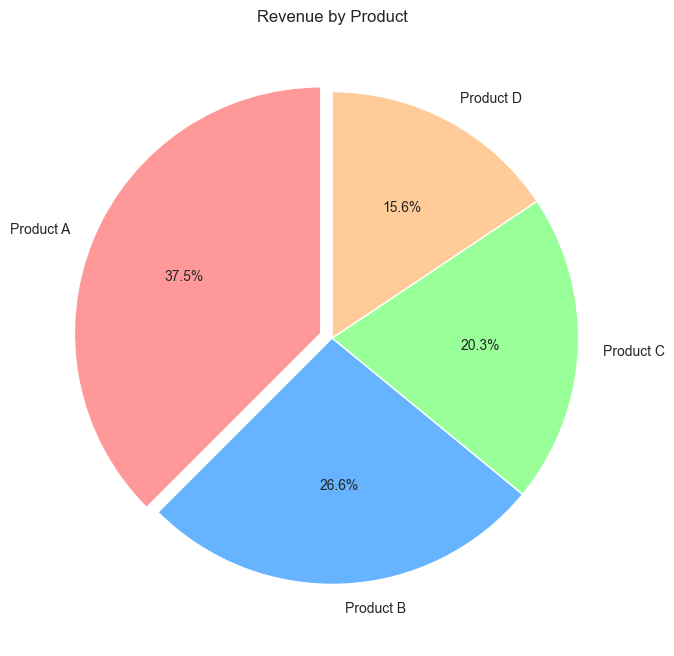

In [26]:
revenue_by_product.set_index('product')['revenue'].plot(
    kind='pie',
    title='Revenue by Product',
    figsize=(10, 8),
    autopct='%1.1f%%',                              # Show percentages
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
    explode=[0.05, 0, 0, 0],                        # Separate first slice
    startangle=90
)
plt.ylabel('')
plt.show()

---

## Multiple Subplots: Comparing Several Metrics

**What it does:** Subplots arrange multiple plots in a grid, letting you compare different visualizations side-by-side.

**When to use:** Comparing multiple metrics, showing before/after, displaying different aspects of the same data.

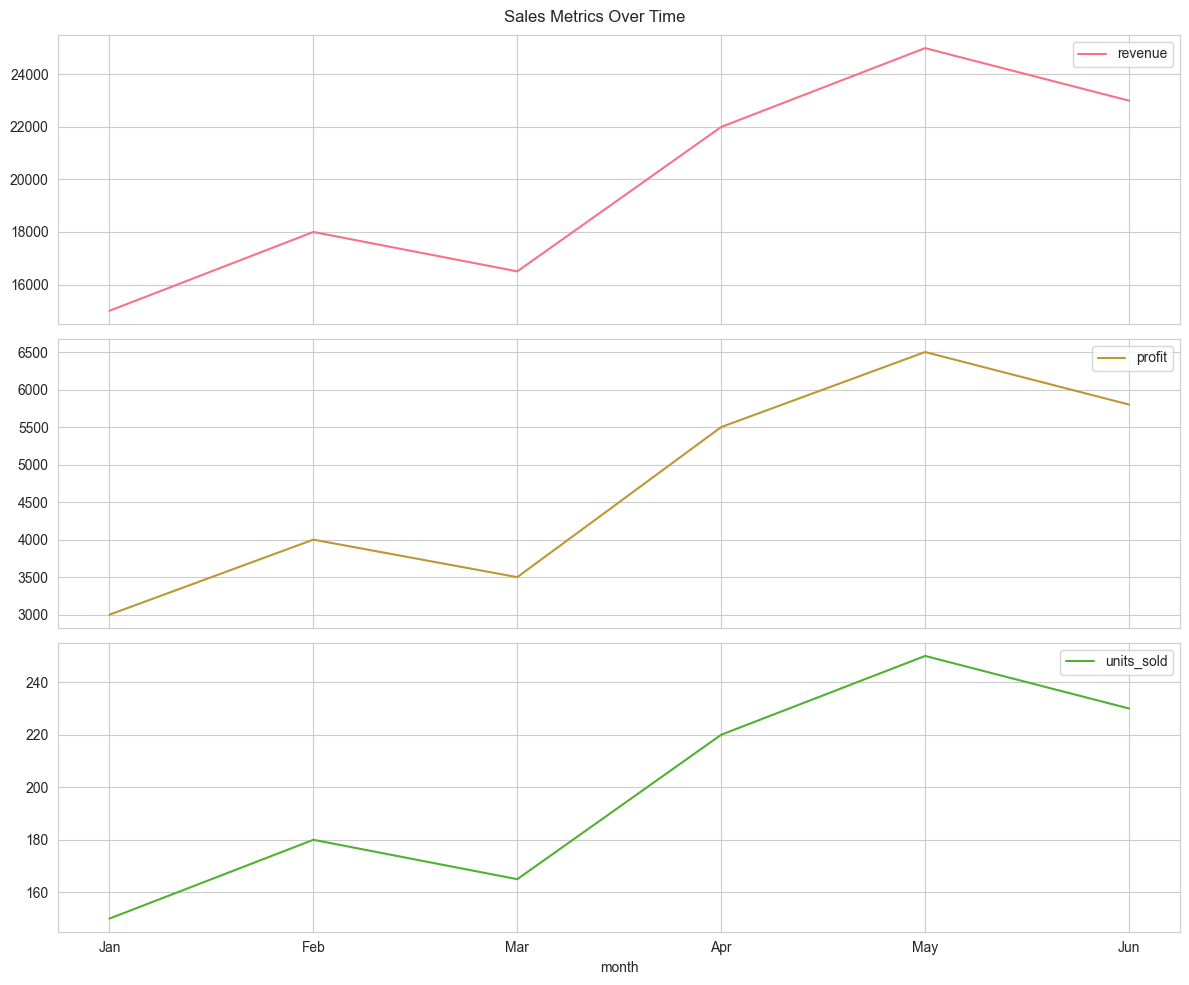

In [27]:
# Create sample data with multiple metrics
sales_metrics = pd.DataFrame({
    'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'revenue': [15000, 18000, 16500, 22000, 25000, 23000],
    'profit': [3000, 4000, 3500, 5500, 6500, 5800],
    'units_sold': [150, 180, 165, 220, 250, 230]
})

# Create separate subplots for each metric
sales_metrics.set_index('month')[['revenue', 'profit', 'units_sold']].plot(
    subplots=True,
    figsize=(12, 10),
    title='Sales Metrics Over Time'
)
plt.tight_layout()
plt.show()

### Side-by-Side Subplots

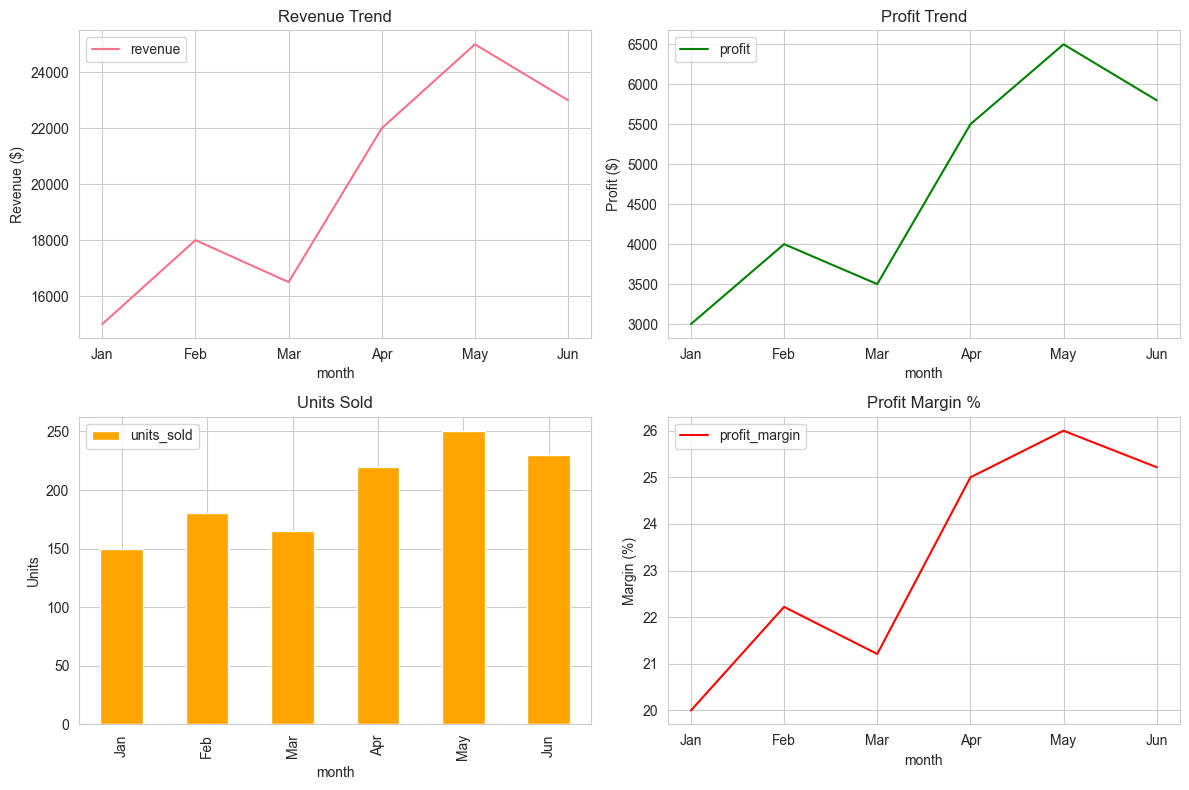

In [28]:
# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Revenue trend (top-left)
sales_metrics.plot(x='month', y='revenue', kind='line', ax=axes[0, 0], title='Revenue Trend')
axes[0, 0].set_ylabel('Revenue ($)')

# Plot 2: Profit trend (top-right)
sales_metrics.plot(x='month', y='profit', kind='line', ax=axes[0, 1], title='Profit Trend', color='green')
axes[0, 1].set_ylabel('Profit ($)')

# Plot 3: Units sold (bottom-left)
sales_metrics.plot(x='month', y='units_sold', kind='bar', ax=axes[1, 0], title='Units Sold', color='orange')
axes[1, 0].set_ylabel('Units')

# Plot 4: Profit margin (bottom-right)
sales_metrics['profit_margin'] = (sales_metrics['profit'] / sales_metrics['revenue'] * 100)
sales_metrics.plot(x='month', y='profit_margin', kind='line', ax=axes[1, 1], title='Profit Margin %', color='red')
axes[1, 1].set_ylabel('Margin (%)')

plt.tight_layout()
plt.show()

---

## Customization Basics: Making Your Plots Professional

### Common Customization Parameters

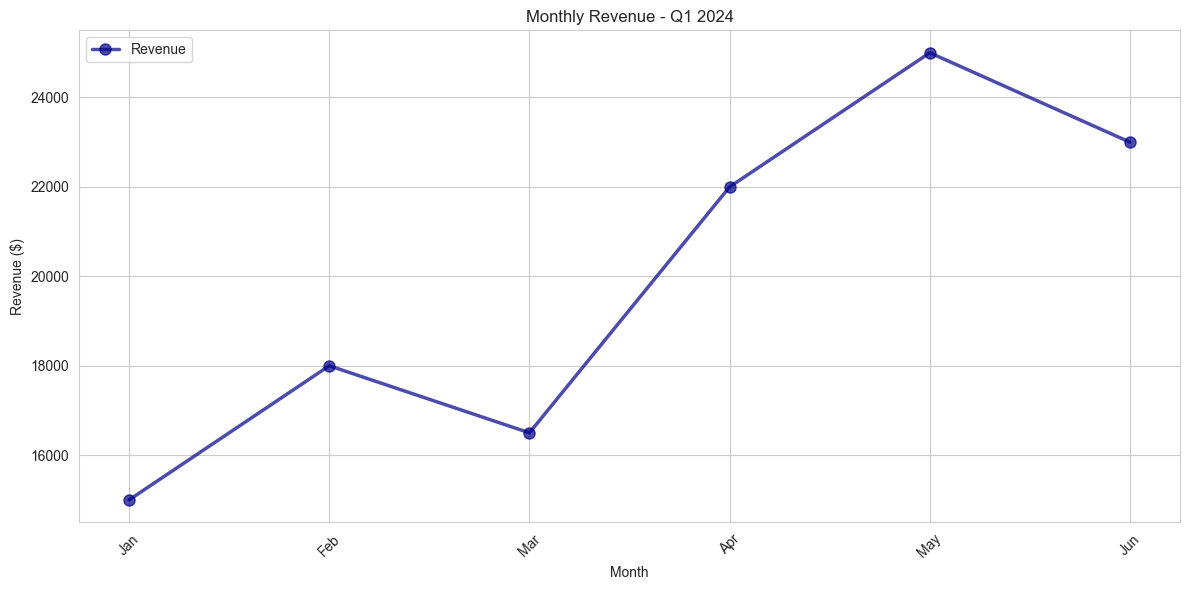

In [29]:
# Comprehensive customization example
sales_metrics.plot(
    x='month',
    y='revenue',
    kind='line',

    # Size and layout
    figsize=(12, 6),            # Width, Height in inches

    # Appearance
    title='Monthly Revenue - Q1 2024',
    color='darkblue',
    linewidth=2.5,
    marker='o',                 # Add markers at data points
    markersize=8,

    # Labels
    xlabel='Month',
    ylabel='Revenue ($)',

    # Grid
    grid=True,
    alpha=0.7                   # Transparency
)

# Additional customization with matplotlib
plt.xticks(rotation=45)         # Rotate x-axis labels
plt.legend(['Revenue'], loc='upper left')  # Position legend
plt.tight_layout()              # Prevent label cutoff
plt.show()

### Color Options

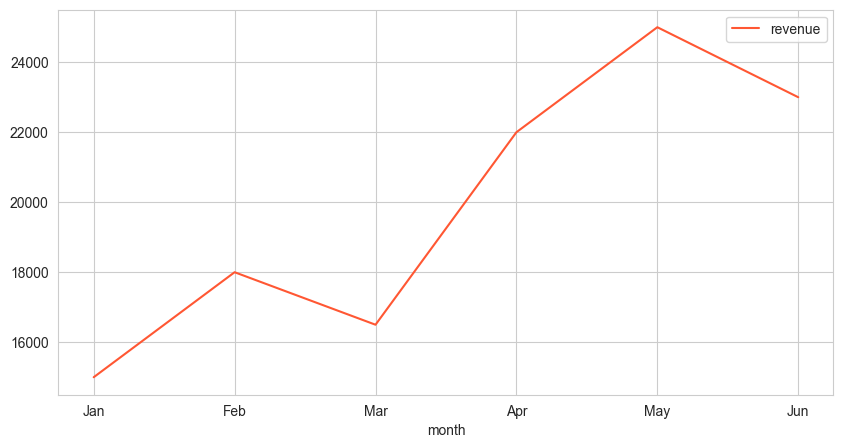

In [30]:
# Named colors
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

# Hex colors (more control)
hex_colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33F5']

# RGB tuples (0-1 scale)
rgb_colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]

# Example usage
sales_metrics.plot(x='month', y='revenue', kind='line', color='#FF5733', figsize=(10, 5))
plt.show()

### Adding Titles and Labels Properly

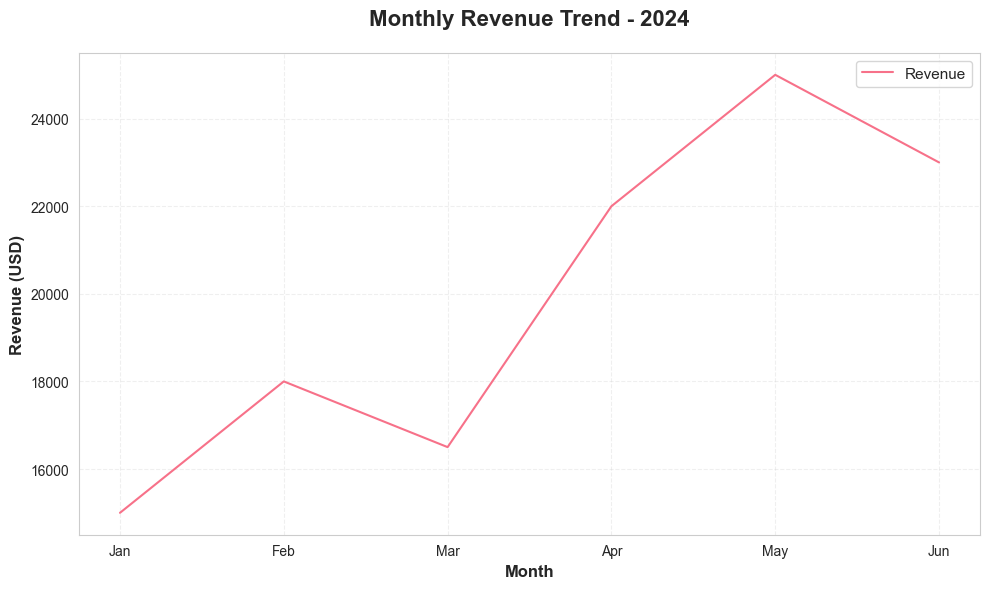

In [31]:
# Complete labeling strategy
ax = sales_metrics.plot(x='month', y='revenue', kind='line', figsize=(10, 6))

# Main title
ax.set_title('Monthly Revenue Trend - 2024', fontsize=16, fontweight='bold', pad=20)

# Axis labels with units
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue (USD)', fontsize=12, fontweight='bold')

# Legend
ax.legend(['Revenue'], fontsize=11, loc='best')

# Grid for readability
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

---

## Pandas `.plot()` vs. Matplotlib `plt.plot()`: When to Use Each

| Feature | Pandas `.plot()` | Matplotlib `plt.plot()` |
|---|---|---|
| **Ease of use** | Simple, one-liner | More verbose |
| **Works with** | DataFrames/Series | Arrays/lists |
| **Best for** | Quick exploration | Complex customization |
| **GroupBy integration** | Native support | Requires manual grouping |
| **Example** | `df.plot(kind='line')` | `plt.plot(df['col'])` |

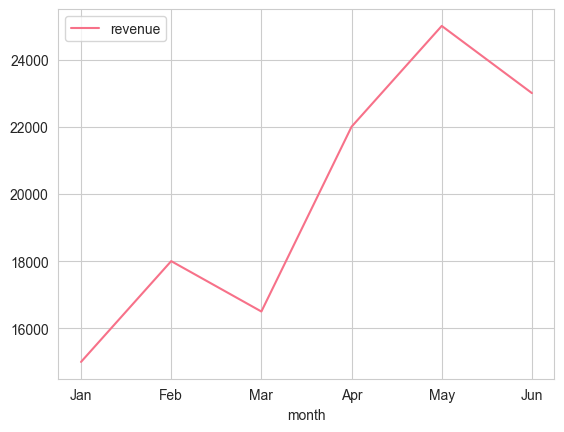

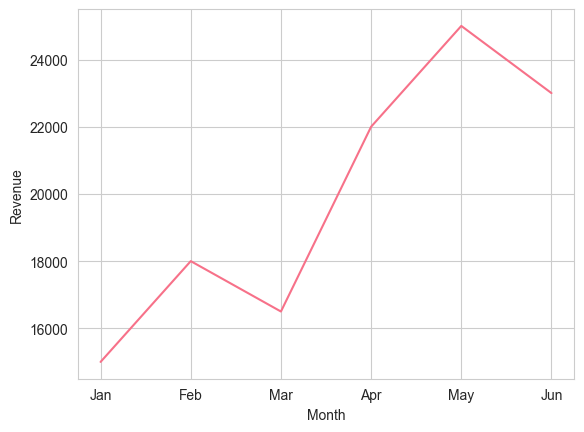

In [32]:
# Pandas approach (simpler for DataFrames)
sales_metrics.plot(x='month', y='revenue', kind='line')
plt.show()

# Matplotlib approach (more control, but more code)
plt.plot(sales_metrics['month'], sales_metrics['revenue'])
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

---

## Saving Your Plots to Files

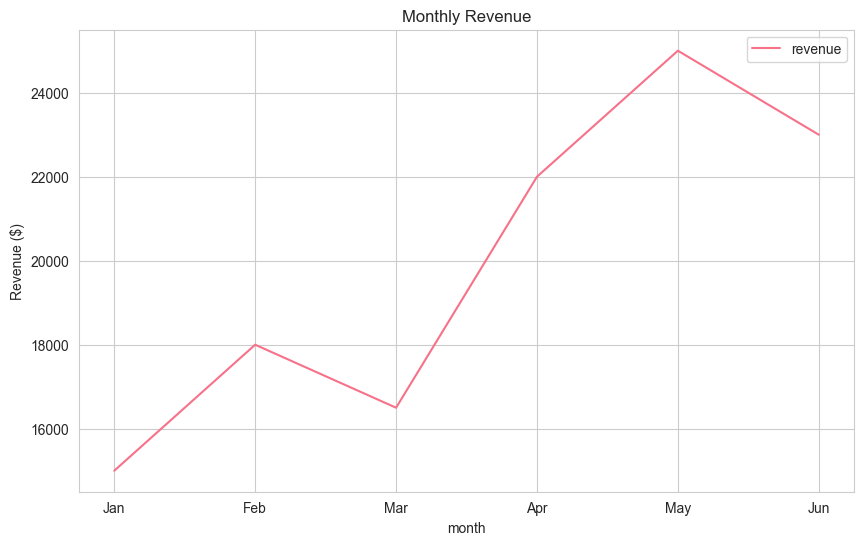

In [33]:
# Create and save a plot
ax = sales_metrics.plot(x='month', y='revenue', kind='line', figsize=(10, 6))
ax.set_title('Monthly Revenue')
ax.set_ylabel('Revenue ($)')

# Save to file (before plt.show())
plt.savefig('revenue_chart.png', dpi=300, bbox_inches='tight')
# dpi=300: High resolution for printing
# bbox_inches='tight': Remove extra whitespace

plt.show()

---

## Common Plotting Mistakes and How to Fix Them

### Mistake 1: Overlapping Labels

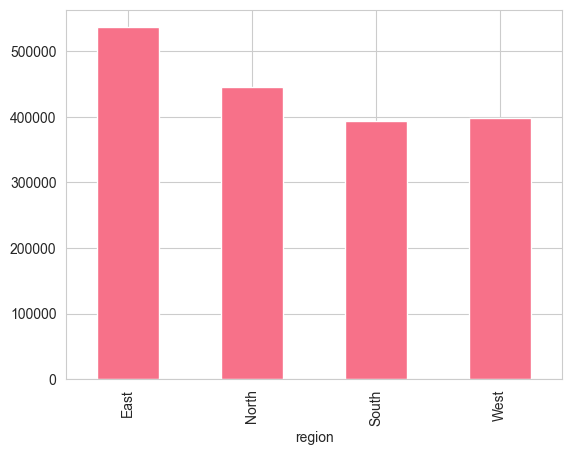

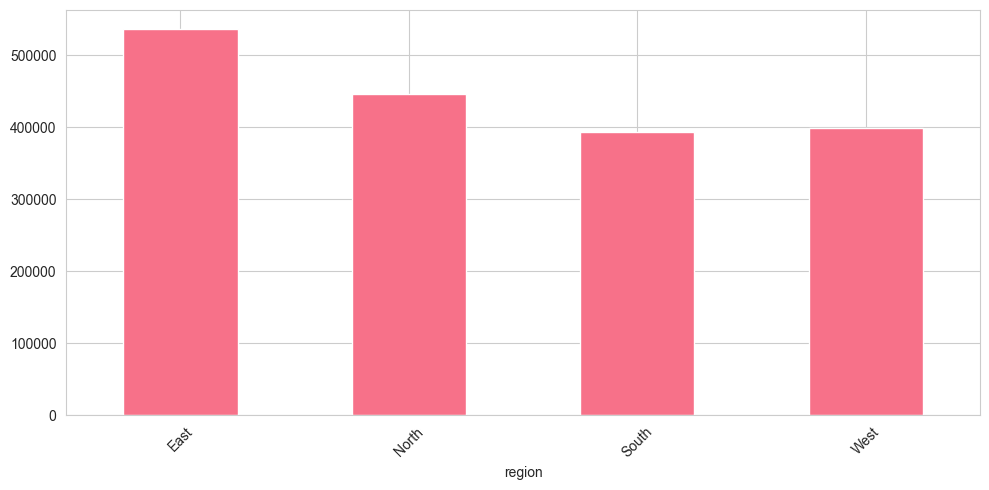

In [34]:
# ❌ WRONG: Labels overlap and are unreadable
sales_by_region_detail.groupby('region')['revenue'].sum().plot(kind='bar')
plt.show()

# ✅ CORRECT: Rotate labels and adjust layout
sales_by_region_detail.groupby('region')['revenue'].sum().plot(kind='bar', figsize=(10, 5))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Mistake 2: Plot Too Small to Read

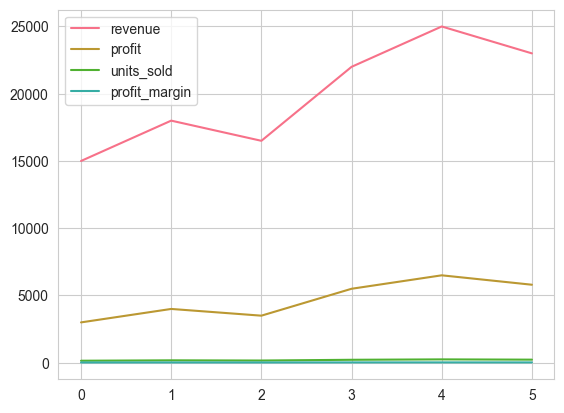

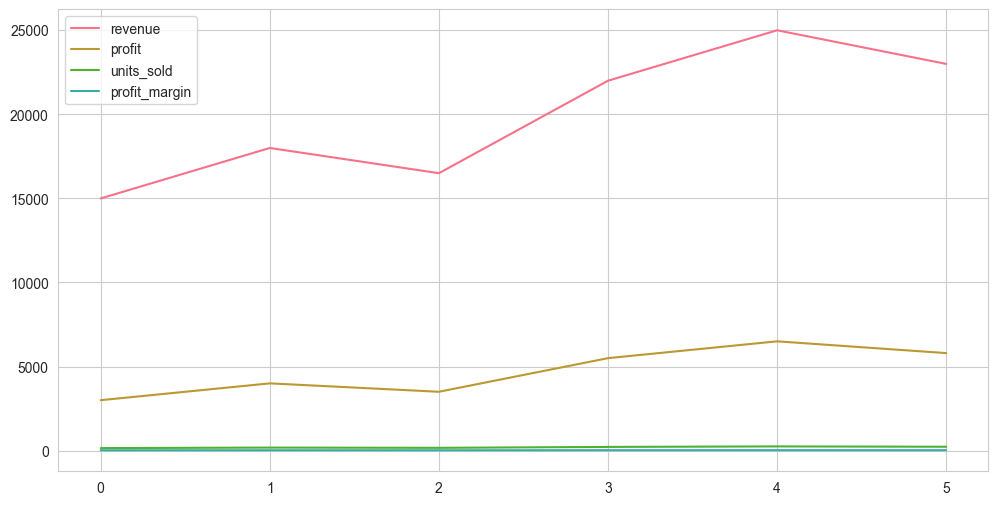

In [35]:
# ❌ WRONG: Default size is too small
sales_metrics.plot(kind='line')
plt.show()

# ✅ CORRECT: Specify figsize
sales_metrics.plot(kind='line', figsize=(12, 6))
plt.show()

### Mistake 3: Missing Data Handling

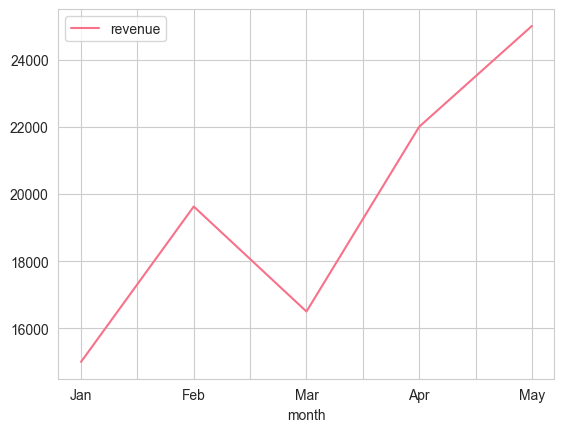

In [36]:
# ❌ WRONG: Missing values can create gaps or errors
sales_with_missing = pd.DataFrame({
    'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
    'revenue': [15000, None, 16500, 22000, 25000]  # Feb is missing
})

# ✅ CORRECT: Handle missing values before plotting
sales_with_missing['revenue'] = sales_with_missing['revenue'].fillna(
    sales_with_missing['revenue'].mean()  # Fill with average
)
sales_with_missing.plot(x='month', y='revenue', kind='line')
plt.show()

### Mistake 4: Forgetting to Add a Legend

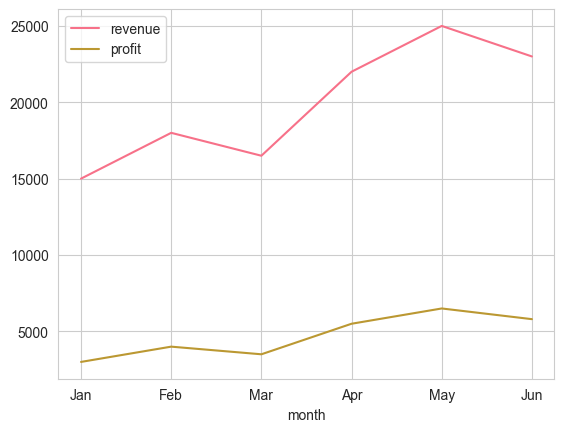

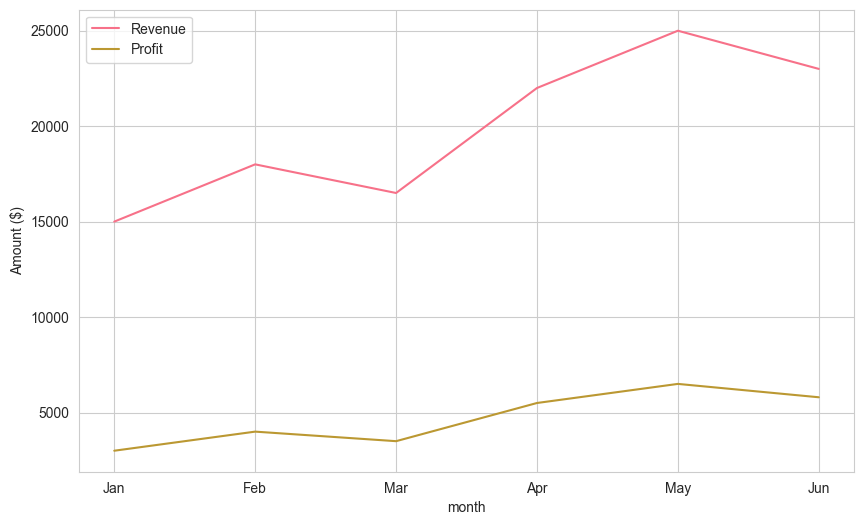

In [37]:
# ❌ WRONG: Multiple lines without labels
sales_metrics.plot(x='month', y=['revenue', 'profit'], kind='line')
plt.show()

# ✅ CORRECT: Add legend to identify lines
sales_metrics.plot(x='month', y=['revenue', 'profit'], kind='line', figsize=(10, 6))
plt.legend(['Revenue', 'Profit'], loc='best')
plt.ylabel('Amount ($)')
plt.show()

### Mistake 5: Poor Color Choices

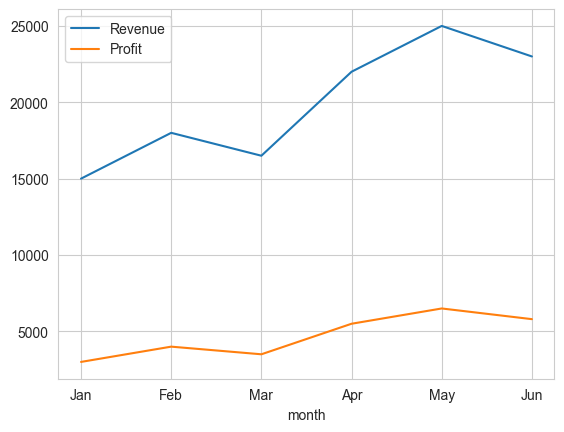

In [38]:
# ✅ CORRECT: Use accessible, distinct colors
sales_metrics.plot(x='month', y=['revenue', 'profit'], kind='line',
                   color=['#1f77b4', '#ff7f0e'])  # Blue and orange
plt.legend(['Revenue', 'Profit'])
plt.show()

---

## Performance Considerations: Plotting Large Datasets

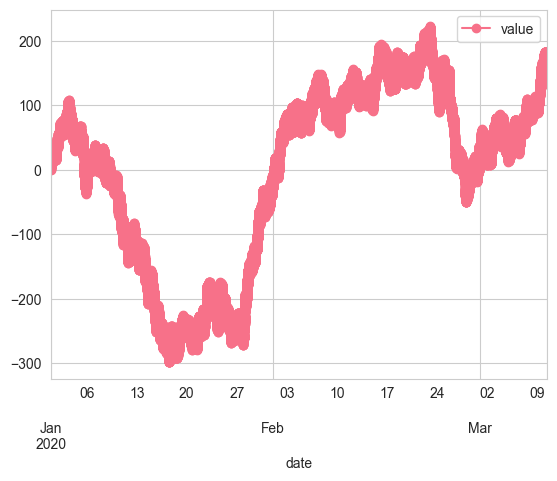

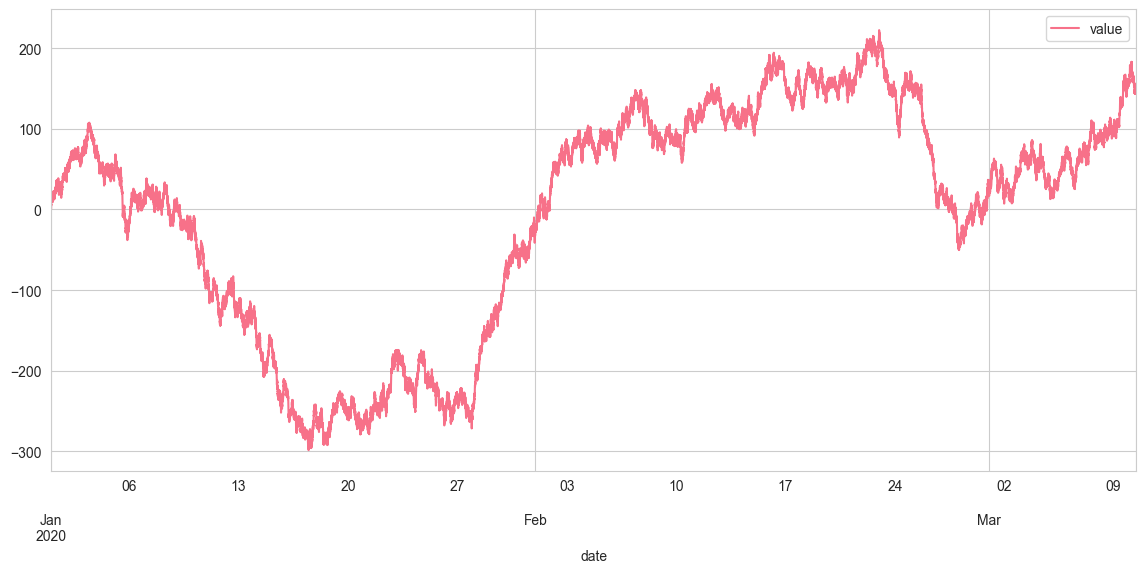

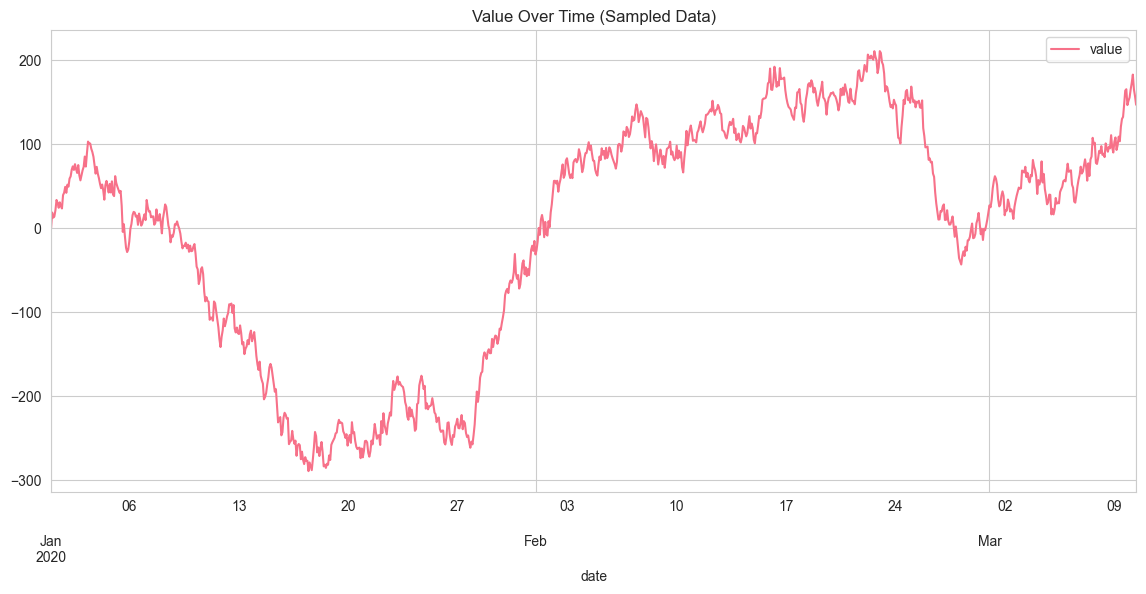

In [39]:
# Create a large dataset
large_data = pd.DataFrame({
    'date': pd.date_range('2020-01-01', periods=100000, freq='1min'),
    'value': np.random.randn(100000).cumsum()
})

# ❌ SLOW: Plotting 100,000 points with markers
large_data.plot(x='date', y='value', marker='o')  # Very slow!
plt.show()

# ✅ FAST: Remove markers for large datasets
large_data.plot(x='date', y='value', kind='line', figsize=(14, 6))
plt.show()

# ✅ BETTER: Sample data for visualization
large_data_sample = large_data.iloc[::100]  # Every 100th point
large_data_sample.plot(x='date', y='value', kind='line', figsize=(14, 6))
plt.title('Value Over Time (Sampled Data)')
plt.show()

---

## Summary: Quick Reference

| Task | Code |
|---|---|
| Line plot | `df.plot(x='col1', y='col2', kind='line')` |
| Bar plot | `df.plot(x='col1', y='col2', kind='bar')` |
| Histogram | `df['col'].plot(kind='hist', bins=20)` |
| Scatter plot | `df.plot(x='col1', y='col2', kind='scatter')` |
| Box plot | `df.boxplot(column='col', by='group')` |
| Pie chart | `df.set_index('col1')['col2'].plot(kind='pie')` |
| Subplots | `df.plot(subplots=True)` |
| Save plot | `plt.savefig('filename.png', dpi=300)` |
| Customize | `df.plot(..., figsize=(10,6), color='blue', title='Title')` |

These basic plots help you quickly understand your data's structure and trends. Start with simple plots to explore your data, then customize as needed for presentations and reports.

---

# Customizing Plots and Visualization Best Practices

Great visualizations are clear, accurate, and visually appealing. Pandas, Matplotlib, and Seaborn offer powerful customization options to help you communicate your data effectively.

---

## Understanding the Visualization Workflow

Before diving into customization, let's set up the essential imports and create sample data:

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create sample data for examples
sales = pd.DataFrame({
    'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'revenue': [15000, 18000, 16500, 22000, 25000, 23000],
    'profit': [3000, 4200, 3800, 5500, 6200, 5800],
    'visits': [1200, 1450, 1380, 1850, 2100, 1950]
})

print(sales)  # Always inspect your data first!

  month  revenue  profit  visits
0   Jan    15000    3000    1200
1   Feb    18000    4200    1450
2   Mar    16500    3800    1380
3   Apr    22000    5500    1850
4   May    25000    6200    2100
5   Jun    23000    5800    1950


**Key Imports Explained:**
- `matplotlib.pyplot` (as `plt`): The core plotting library
- `seaborn` (as `sns`): Built on Matplotlib; provides refined defaults and statistical visualizations
- `plt.show()`: Displays plots in scripts (Jupyter notebooks auto-display)

---

## Customizing Plot Appearance

### Basic Customization: Titles, Labels, and Colors

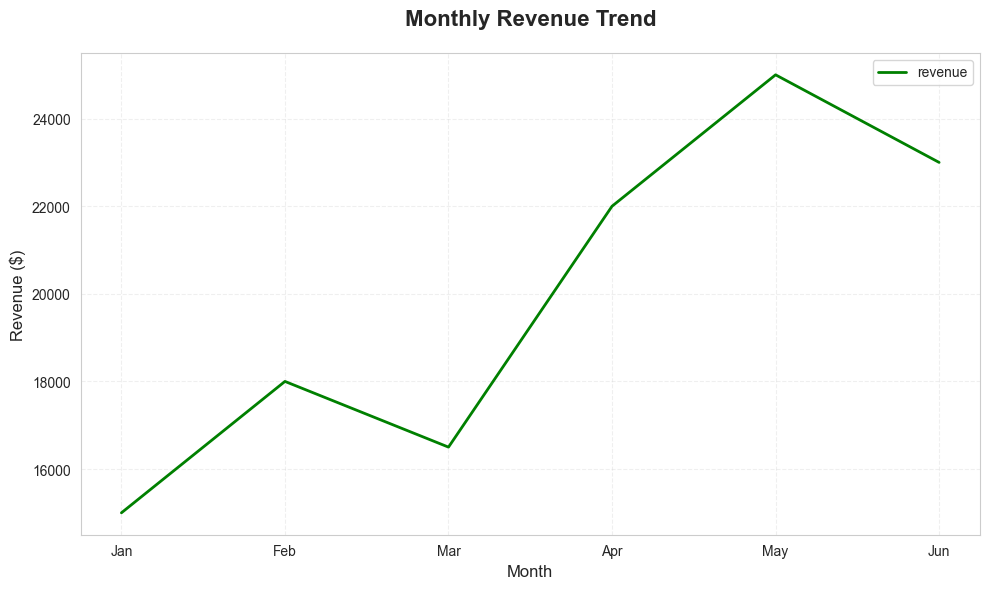

In [41]:
# Create a figure with specified size
fig, ax = plt.subplots(figsize=(10, 6))

# Line plot with customizations
sales.plot(x='month', y='revenue', kind='line', color='green', ax=ax, linewidth=2)

# Add labels and title
ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue ($)', fontsize=12)

# Add gridlines for readability
ax.grid(True, alpha=0.3, linestyle='--')

# Improve layout to prevent label cutoff
plt.tight_layout()
plt.show()

**Parameters Explained:**
- `figsize=(10, 6)`: Width and height in inches
- `linewidth=2`: Thickness of the line
- `fontsize`: Text size (larger = more prominent)
- `alpha=0.3`: Transparency (0 = invisible, 1 = opaque)
- `tight_layout()`: Automatically adjusts spacing to prevent labels from being cut off

---

## Choosing the Right Plot Type

Different data types require different visualizations. Use this decision framework to select the most effective chart:

| Question | Answer | Plot Type | Example |
|----------|--------|-----------|---------|
| Showing **trends over time**? | Yes | **Line** | Stock prices, monthly sales |
| Comparing **categories**? | Yes | **Bar** | Sales by region, product comparison |
| Showing **relationships** between two variables? | Yes | **Scatter** | Price vs. quality, height vs. weight |
| Showing **distribution** of a single variable? | Yes | **Histogram** | Age distribution, test scores |
| Showing **part-to-whole** relationships? | Yes | **Pie** | Market share, budget allocation |
| Showing **stacked categories over time**? | Yes | **Area** | Revenue by product line over months |

### Plot Type Examples

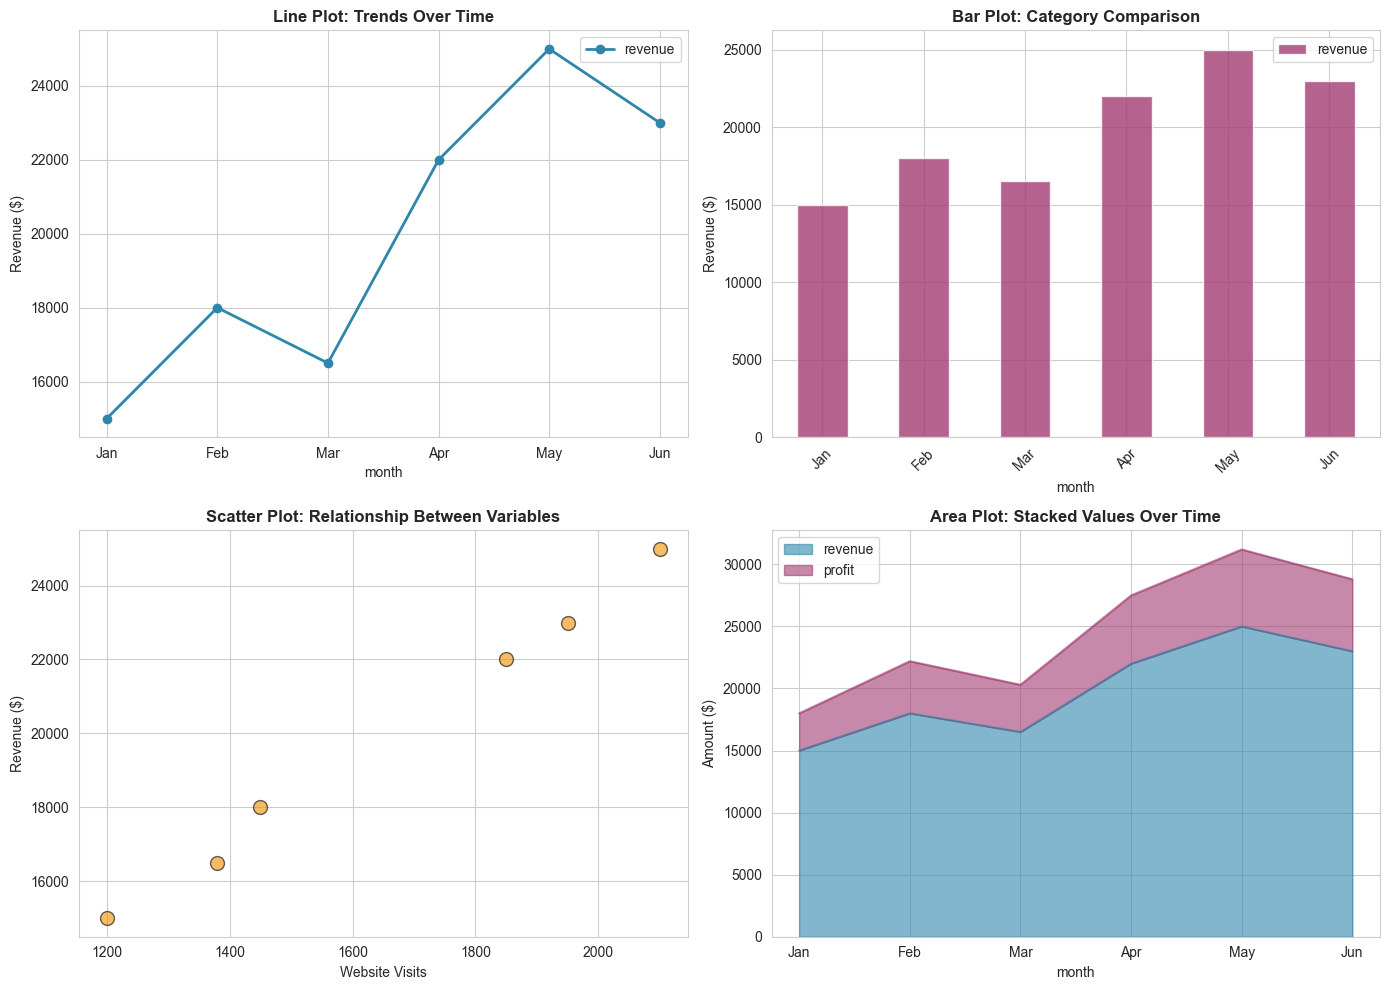

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. LINE PLOT - Best for trends over time
sales.plot(x='month', y='revenue', kind='line', ax=axes[0, 0],
           marker='o', color='#2E86AB', linewidth=2)
axes[0, 0].set_title('Line Plot: Trends Over Time', fontweight='bold')
axes[0, 0].set_ylabel('Revenue ($)')

# 2. BAR PLOT - Best for comparing categories
sales.plot(x='month', y='revenue', kind='bar', ax=axes[0, 1],
           color='#A23B72', alpha=0.8)
axes[0, 1].set_title('Bar Plot: Category Comparison', fontweight='bold')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. SCATTER PLOT - Best for relationships
axes[1, 0].scatter(sales['visits'], sales['revenue'],
                   s=100, color='#F18F01', alpha=0.6, edgecolors='black')
axes[1, 0].set_title('Scatter Plot: Relationship Between Variables', fontweight='bold')
axes[1, 0].set_xlabel('Website Visits')
axes[1, 0].set_ylabel('Revenue ($)')

# 4. AREA PLOT - Best for stacked categories
sales.plot(x='month', y=['revenue', 'profit'], kind='area', ax=axes[1, 1],
           alpha=0.6, color=['#2E86AB', '#A23B72'])
axes[1, 1].set_title('Area Plot: Stacked Values Over Time', fontweight='bold')
axes[1, 1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

---

## Figure Size and Resolution (DPI)

The size and resolution of your plot affect readability and file size:

<Figure size 800x500 with 0 Axes>

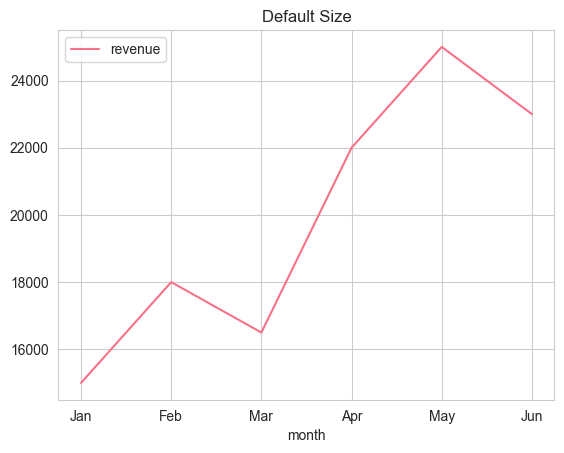

<Figure size 2100x1200 with 0 Axes>

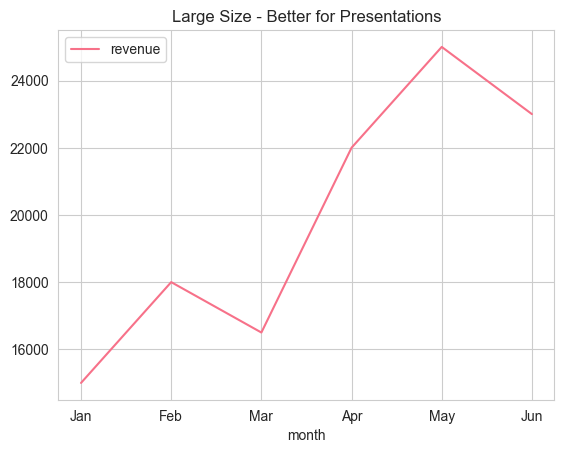

<Figure size 3000x1800 with 0 Axes>

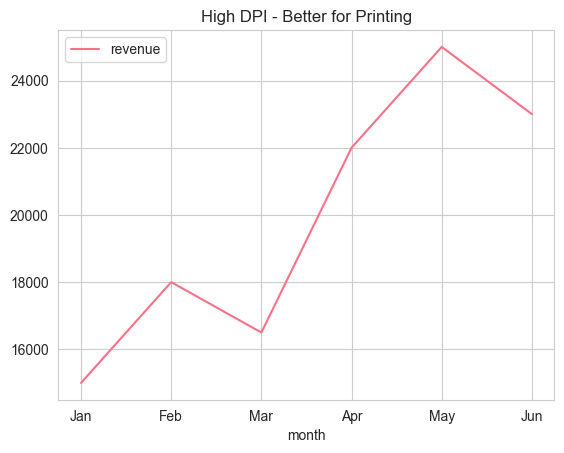

In [43]:
# Small figure for notebooks
plt.figure(figsize=(8, 5), dpi=100)
sales.plot(x='month', y='revenue', kind='line')
plt.title('Default Size')
plt.show()

# Large figure for presentations
plt.figure(figsize=(14, 8), dpi=150)
sales.plot(x='month', y='revenue', kind='line')
plt.title('Large Size - Better for Presentations')
plt.show()

# High-resolution for printing
plt.figure(figsize=(10, 6), dpi=300)
sales.plot(x='month', y='revenue', kind='line')
plt.title('High DPI - Better for Printing')
plt.savefig('revenue_chart.png', dpi=300, bbox_inches='tight')
plt.show()

**DPI Guidelines:**
- `dpi=72–100`: Screen display (web, notebooks)
- `dpi=150`: Presentations
- `dpi=300`: Print quality

---

## Color Palettes and Accessibility

### Understanding Color Palettes

Colors should clarify your data, not distract from it:

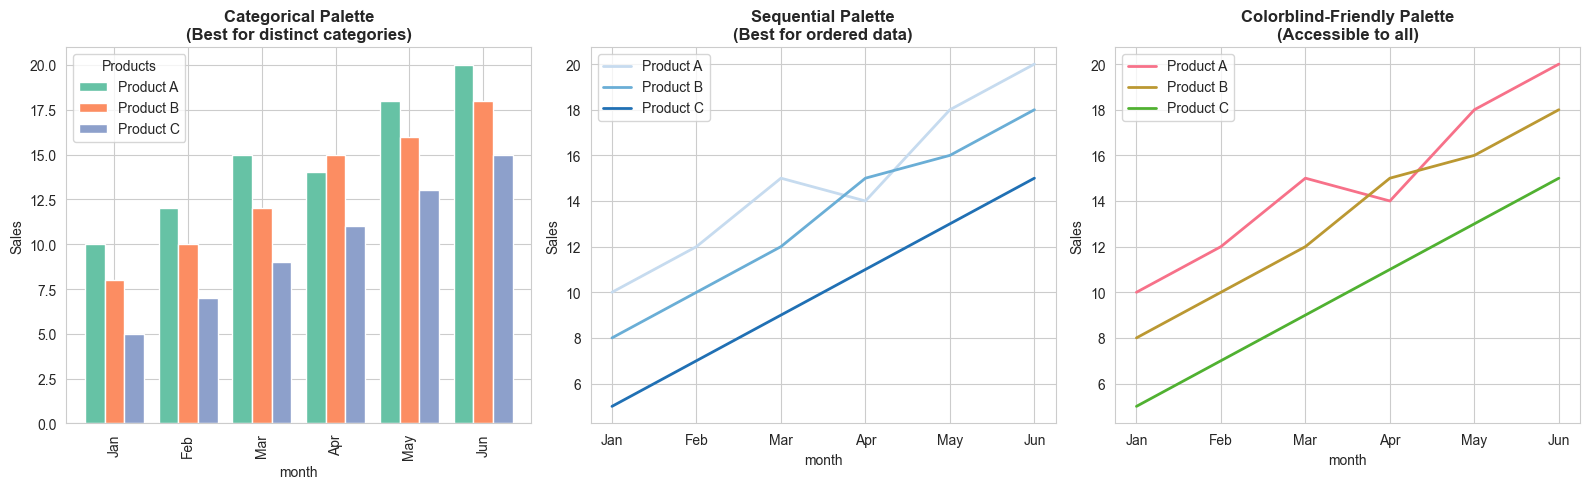

In [44]:
# Create sample multi-series data
multi_data = pd.DataFrame({
    'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Product A': [10, 12, 15, 14, 18, 20],
    'Product B': [8, 10, 12, 15, 16, 18],
    'Product C': [5, 7, 9, 11, 13, 15]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. CATEGORICAL PALETTE - For distinct groups
sns.set_palette("Set2")
multi_data.set_index('month').plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Categorical Palette\n(Best for distinct categories)', fontweight='bold')
axes[0].set_ylabel('Sales')
axes[0].legend(title='Products')

# 2. SEQUENTIAL PALETTE - For ordered data (low to high)
sequential_colors = sns.color_palette("Blues", 3)
multi_data.set_index('month').plot(kind='line', ax=axes[1],
                                    color=sequential_colors, linewidth=2)
axes[1].set_title('Sequential Palette\n(Best for ordered data)', fontweight='bold')
axes[1].set_ylabel('Sales')

# 3. COLORBLIND-FRIENDLY PALETTE - For accessibility
# Important: ~8% of males, ~0.5% of females have color blindness
sns.set_palette("colorblind")
multi_data.set_index('month').plot(kind='line', ax=axes[2], linewidth=2)
axes[2].set_title('Colorblind-Friendly Palette\n(Accessible to all)', fontweight='bold')
axes[2].set_ylabel('Sales')

plt.tight_layout()
plt.show()

### Colorblind-Friendly Best Practices

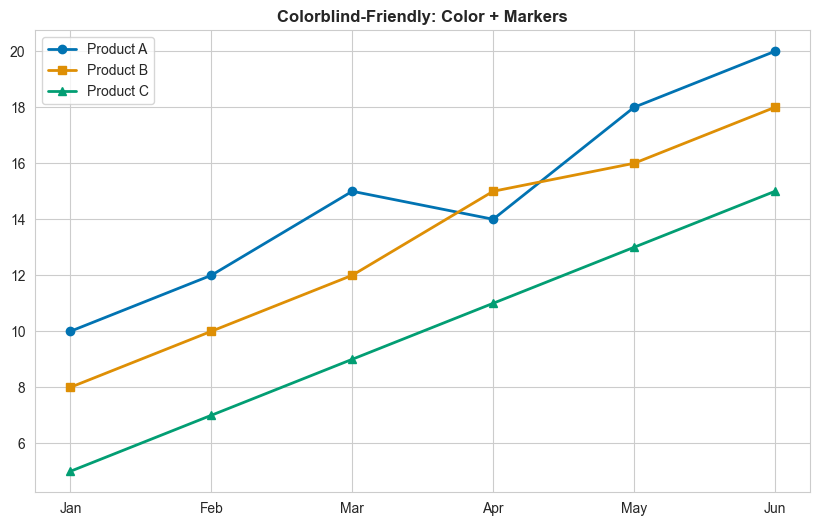

In [45]:
# Best practice: Use color + pattern/marker for maximum accessibility
fig, ax = plt.subplots(figsize=(10, 6))

for i, product in enumerate(['Product A', 'Product B', 'Product C']):
    ax.plot(multi_data['month'], multi_data[product],
            marker=['o', 's', '^'][i],  # Different markers
            linewidth=2, label=product)

ax.set_title('Colorblind-Friendly: Color + Markers', fontweight='bold')
ax.legend()
plt.show()

**Accessible Palettes:**
- `"colorblind"` – Recommended for accessibility
- `"husl"` – Evenly spaced hues
- `"Set1"` – Distinct colors

**Avoid:**
- Red-green combinations (most common colorblindness)
- Pure blue and pure yellow together

---

## Adding Annotations

Annotations highlight important points or trends in your data:

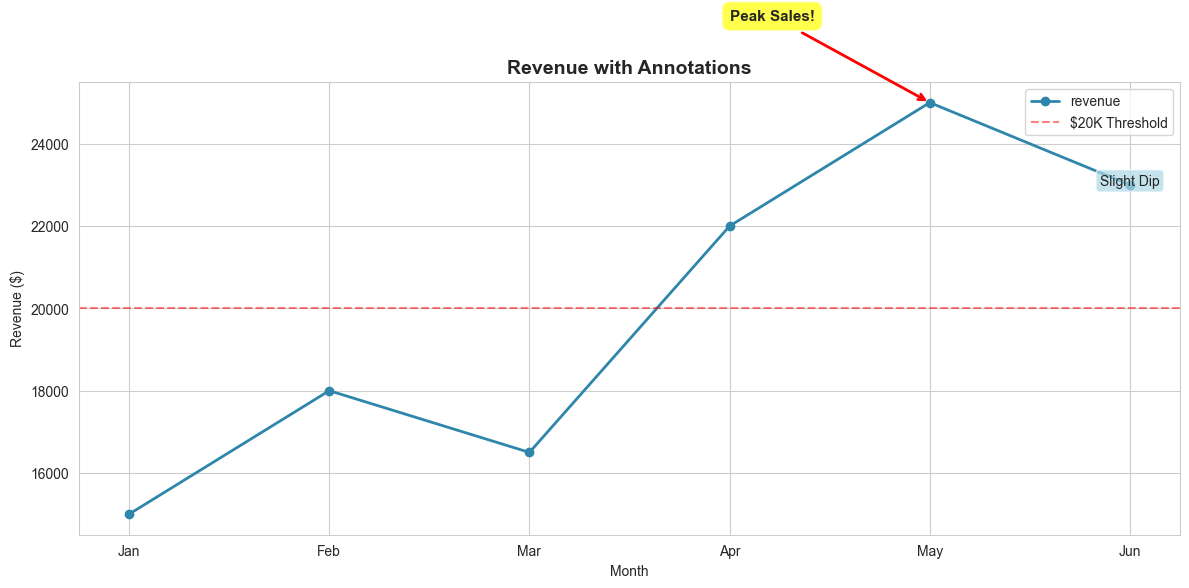

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the data
sales.plot(x='month', y='revenue', kind='line', ax=ax,
           marker='o', linewidth=2, color='#2E86AB')

# ANNOTATION 1: Point annotation with arrow
ax.annotate('Peak Sales!',
            xy=(4, 25000),
            xytext=(3, 27000),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# ANNOTATION 2: Simple text annotation (no arrow)
ax.text(5, 23000, 'Slight Dip',
        fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# ANNOTATION 3: Horizontal line to highlight threshold
ax.axhline(y=20000, color='red', linestyle='--', alpha=0.5, label='$20K Threshold')

ax.set_title('Revenue with Annotations', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.show()

**Annotation Parameters Explained:**
- `xy`: The point on the plot to annotate (data coordinates)
- `xytext`: Where the annotation text appears
- `arrowprops`: Dictionary controlling arrow appearance
- `bbox`: Box around text (background styling)
- `ha='center'`: Horizontal alignment (left, center, right)

---

## Creating Subplots for Comparison

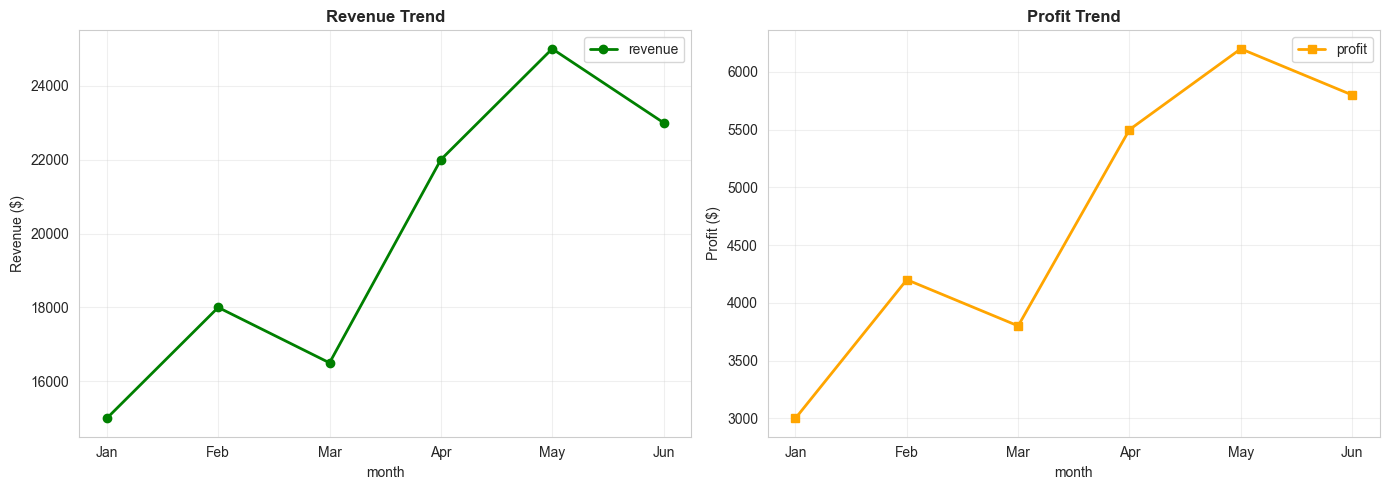

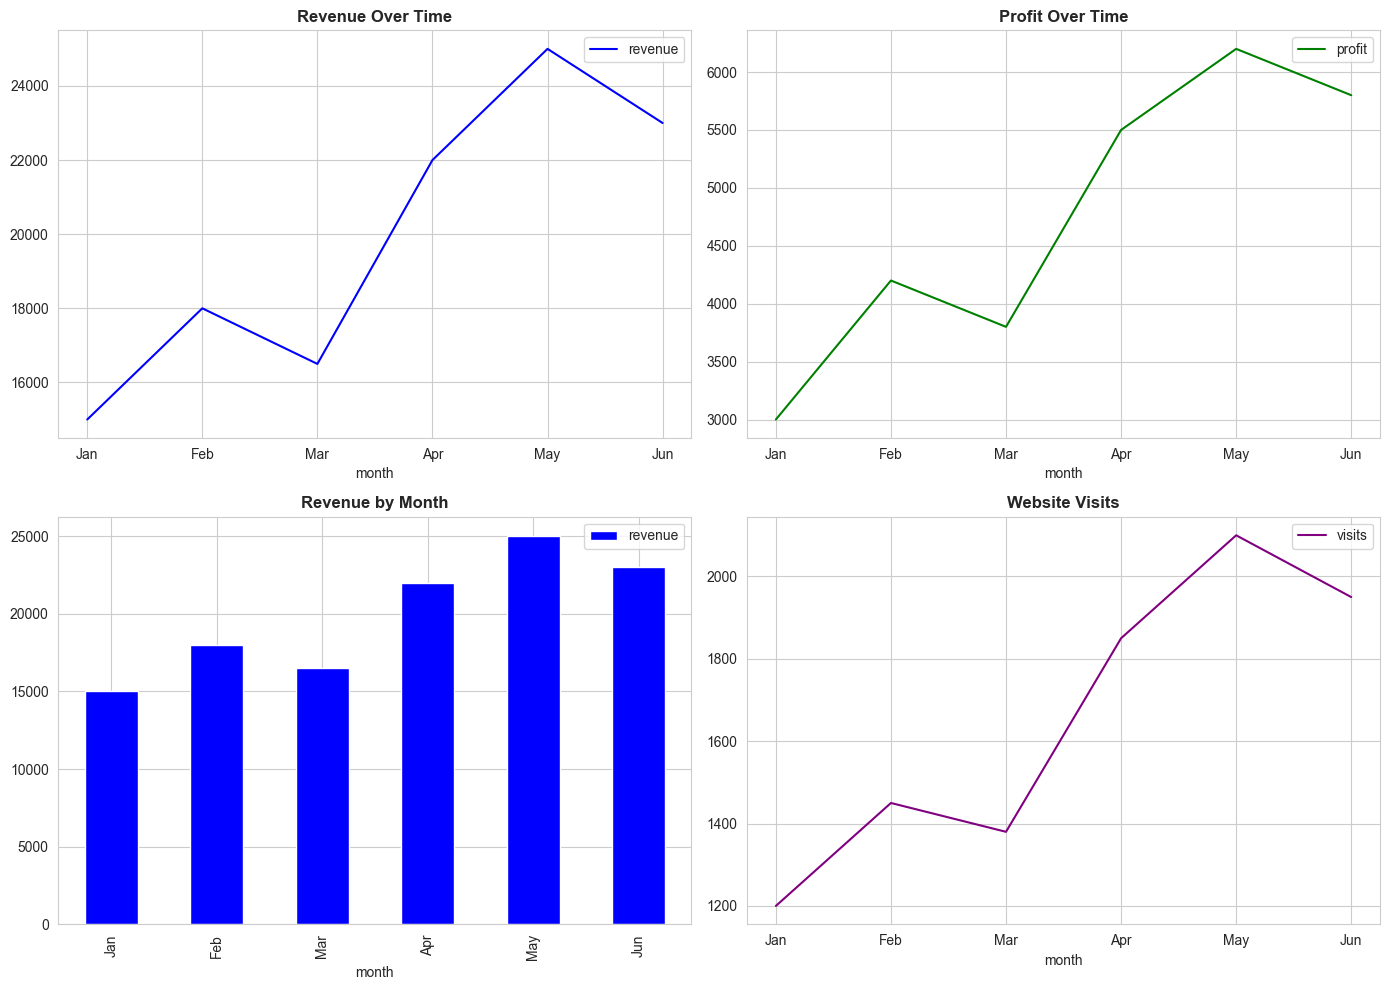

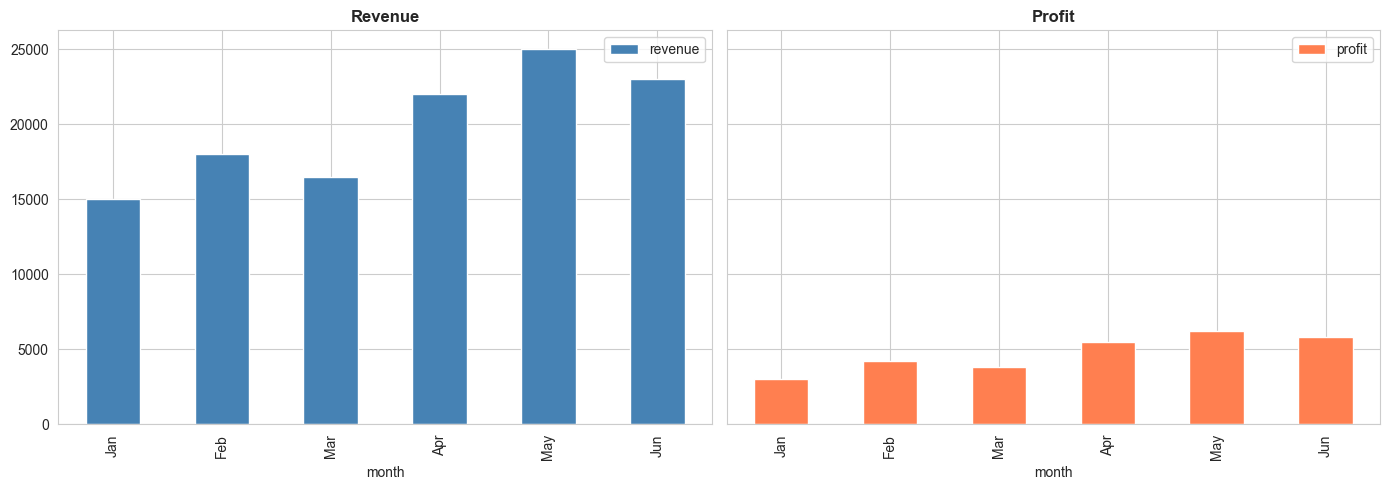

In [47]:
# 1x2 Layout: Two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sales.plot(x='month', y='revenue', kind='line', ax=axes[0],
           marker='o', color='green', linewidth=2)
axes[0].set_title('Revenue Trend', fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(alpha=0.3)

sales.plot(x='month', y='profit', kind='line', ax=axes[1],
           marker='s', color='orange', linewidth=2)
axes[1].set_title('Profit Trend', fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2x2 Layout: Four plots for comprehensive comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sales.plot(x='month', y='revenue', kind='line', ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Revenue Over Time', fontweight='bold')

sales.plot(x='month', y='profit', kind='line', ax=axes[0, 1], color='green')
axes[0, 1].set_title('Profit Over Time', fontweight='bold')

sales.plot(x='month', y='revenue', kind='bar', ax=axes[1, 0], color='blue')
axes[1, 0].set_title('Revenue by Month', fontweight='bold')

sales.plot(x='month', y='visits', kind='line', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Website Visits', fontweight='bold')

plt.tight_layout()
plt.show()

# Sharing axes for consistent scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sales.plot(x='month', y='revenue', kind='bar', ax=axes[0], color='steelblue')
sales.plot(x='month', y='profit', kind='bar', ax=axes[1], color='coral')
axes[0].set_title('Revenue', fontweight='bold')
axes[1].set_title('Profit', fontweight='bold')
plt.tight_layout()
plt.show()

---

## Reducing Visual Clutter (Data-Ink Ratio)

The **data-ink ratio** is the proportion of ink used to show data versus decorative elements. Higher ratios = clearer charts.

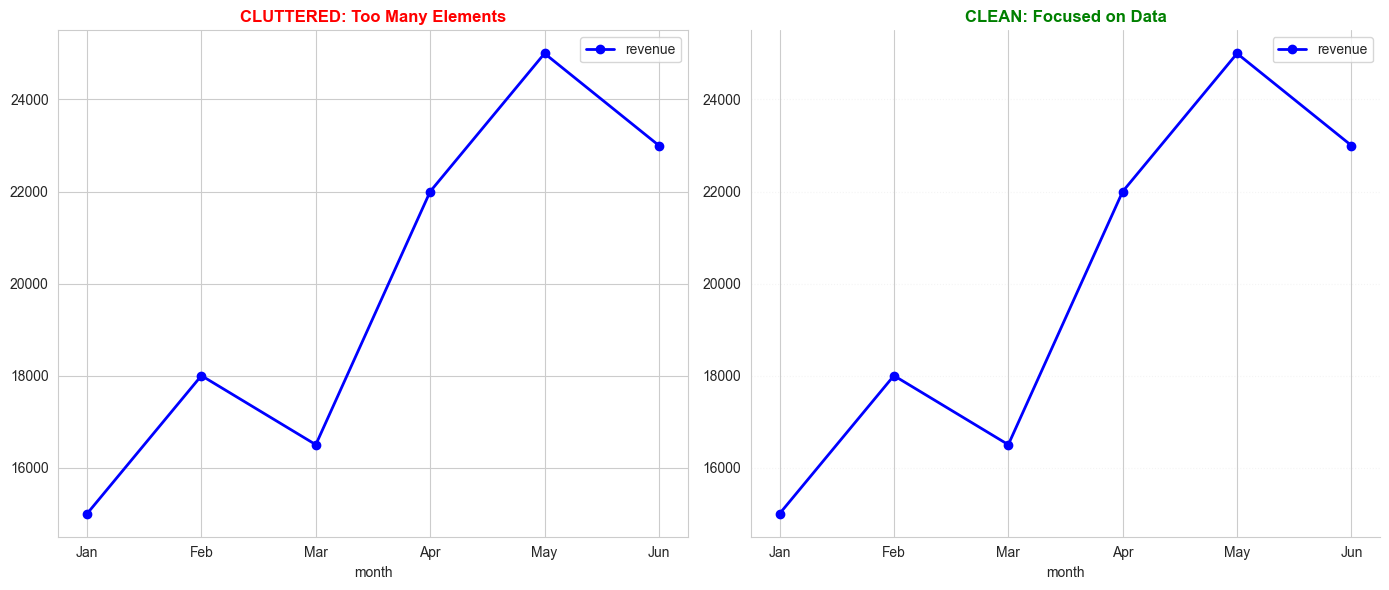

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CLUTTERED VERSION (low data-ink ratio)
sales.plot(x='month', y='revenue', kind='line', ax=axes[0],
           marker='o', linewidth=2, color='blue')
axes[0].set_title('CLUTTERED: Too Many Elements', fontweight='bold', color='red')
axes[0].grid(True)
axes[0].spines['top'].set_visible(True)
axes[0].spines['right'].set_visible(True)

# CLEAN VERSION (high data-ink ratio)
sales.plot(x='month', y='revenue', kind='line', ax=axes[1],
           marker='o', linewidth=2, color='blue')
axes[1].set_title('CLEAN: Focused on Data', fontweight='bold', color='green')

# Remove unnecessary spines (borders)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Only horizontal gridlines, subtle
axes[1].grid(axis='y', alpha=0.2, linestyle=':')

plt.tight_layout()
plt.show()

**Best Practices for Reducing Clutter:**
- Remove top and right spines (borders)
- Use subtle gridlines (low alpha, light color)
- Limit decorative elements
- Use white space effectively
- Keep color palette simple

---

## Formatting Axes and Ticks

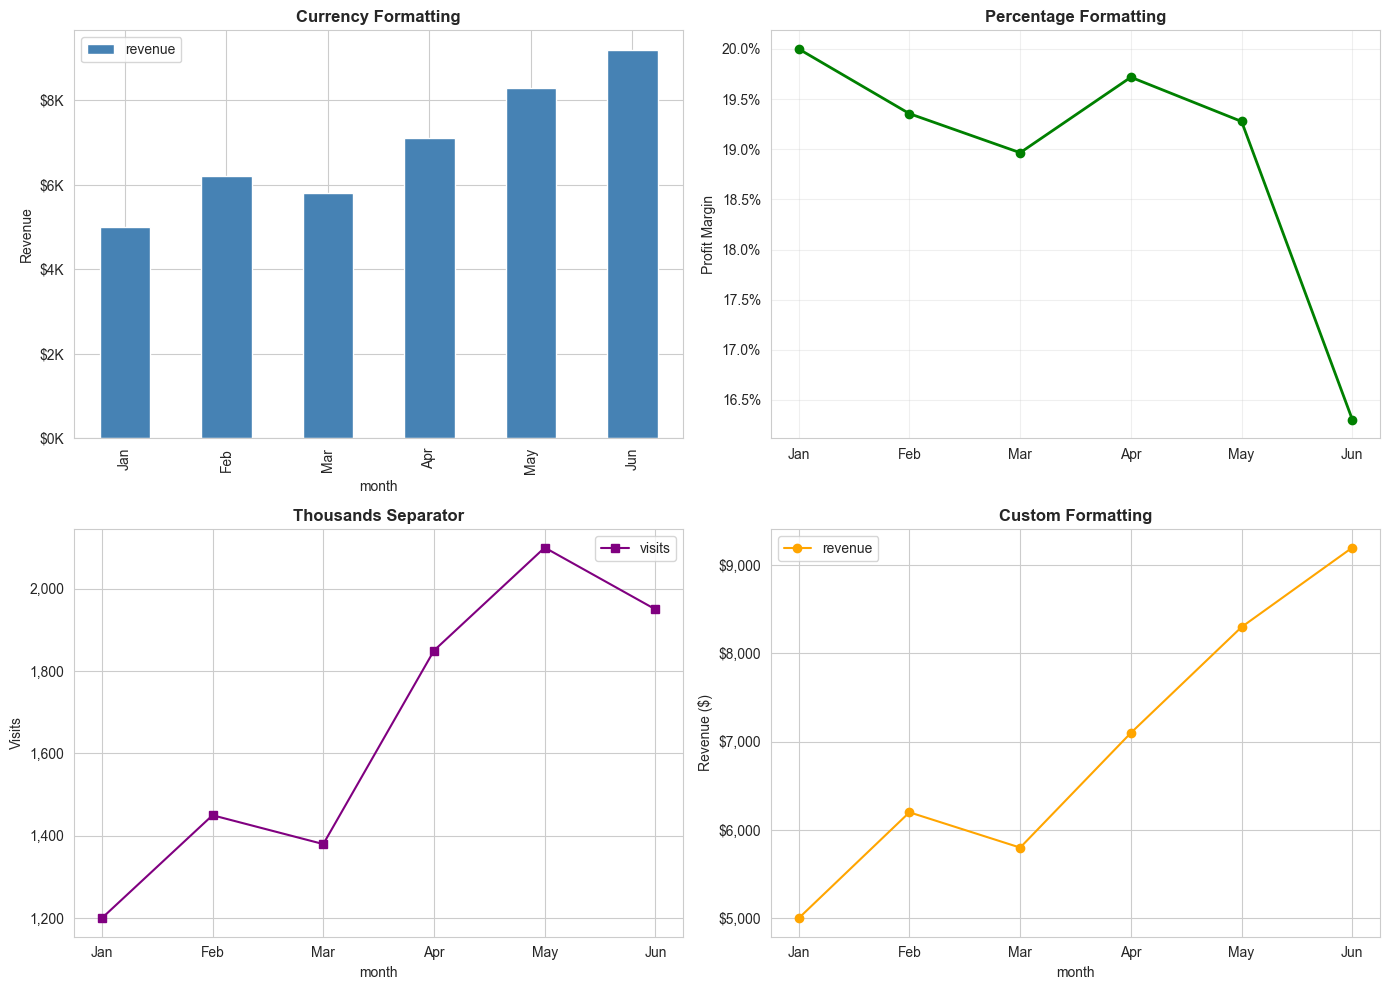

In [49]:
from matplotlib.ticker import FuncFormatter

# Sample data
sales = pd.DataFrame({
    'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'revenue': [5000, 6200, 5800, 7100, 8300, 9200],
    'profit': [1000, 1200, 1100, 1400, 1600, 1500],
    'visits': [1200, 1450, 1380, 1850, 2100, 1950]
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CURRENCY FORMATTING
ax = axes[0, 0]
sales.plot(x='month', y='revenue', kind='bar', ax=ax, color='steelblue')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax.set_title('Currency Formatting', fontweight='bold')
ax.set_ylabel('Revenue')

# 2. PERCENTAGE FORMATTING
ax = axes[0, 1]
profit_margin = (sales['profit'] / sales['revenue'] * 100)
ax.plot(sales['month'], profit_margin, marker='o', linewidth=2, color='green')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.1f}%'))
ax.set_title('Percentage Formatting', fontweight='bold')
ax.set_ylabel('Profit Margin')
ax.grid(alpha=0.3)

# 3. THOUSANDS SEPARATOR
ax = axes[1, 0]
sales.plot(x='month', y='visits', kind='line', ax=ax, marker='s', color='purple')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_title('Thousands Separator', fontweight='bold')
ax.set_ylabel('Visits')

# 4. CUSTOM FORMATTING
ax = axes[1, 1]
sales.plot(x='month', y='revenue', kind='line', ax=ax, marker='o', color='orange')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.set_title('Custom Formatting', fontweight='bold')
ax.set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

---

## Legend Placement and Handling

Legends should enhance, not obscure your data:

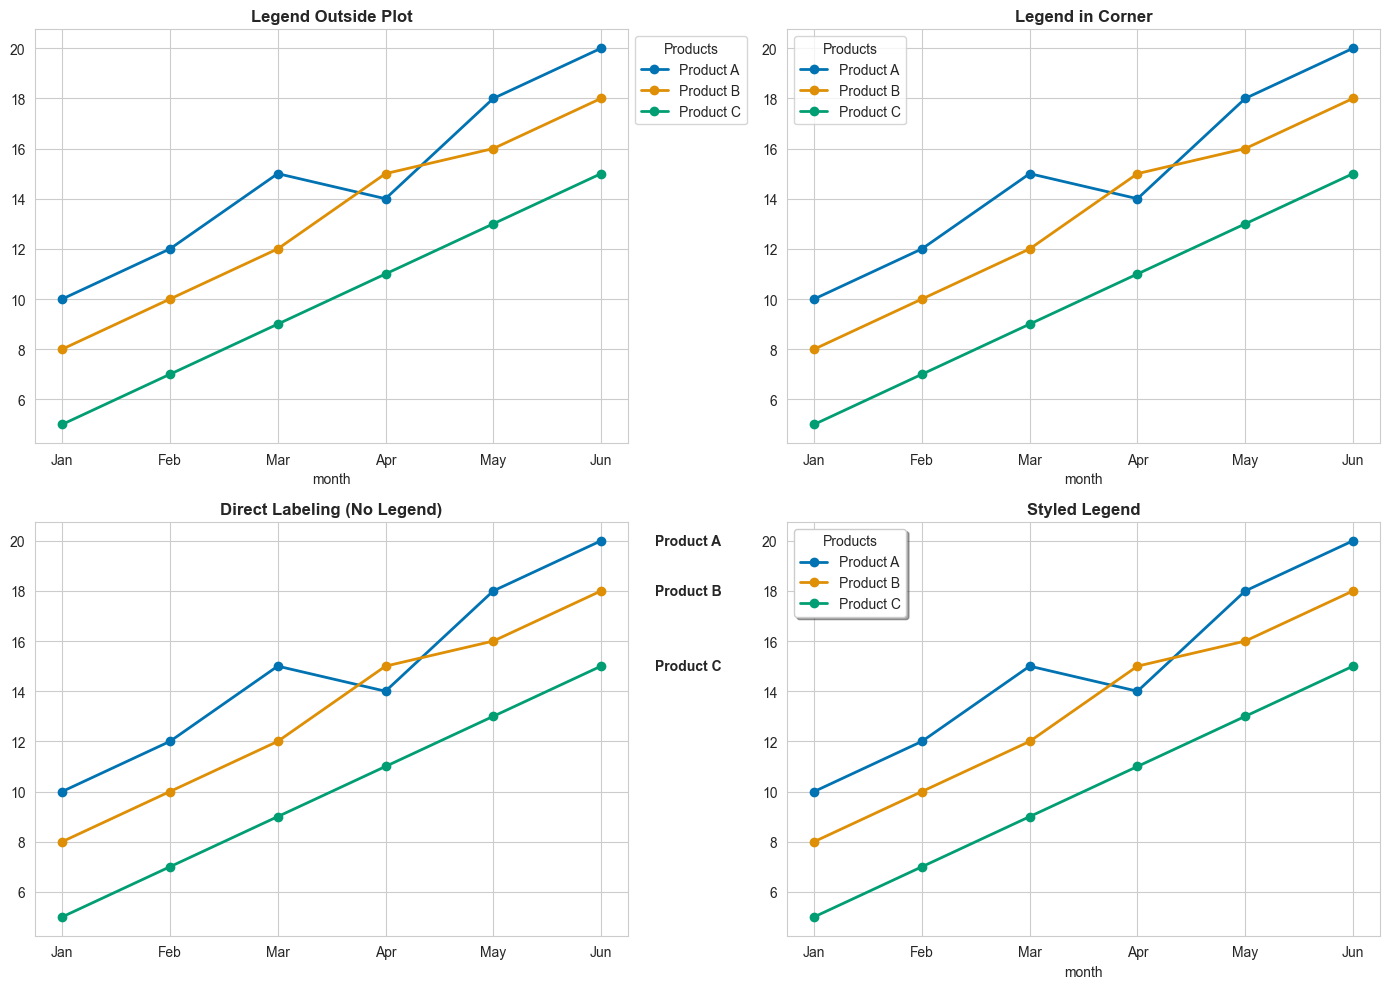

In [50]:
# Create sample multi-series data
multi_data = pd.DataFrame({
    'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Product A': [10, 12, 15, 14, 18, 20],
    'Product B': [8, 10, 12, 15, 16, 18],
    'Product C': [5, 7, 9, 11, 13, 15]
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. LEGEND OUTSIDE (Best practice)
ax = axes[0, 0]
multi_data.set_index('month').plot(kind='line', ax=ax, linewidth=2, marker='o')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Products', frameon=True)
ax.set_title('Legend Outside Plot', fontweight='bold')

# 2. LEGEND IN CORNER (When space allows)
ax = axes[0, 1]
multi_data.set_index('month').plot(kind='line', ax=ax, linewidth=2, marker='o')
ax.legend(loc='upper left', title='Products', frameon=True)
ax.set_title('Legend in Corner', fontweight='bold')

# 3. DIRECT LABELING (Alternative to legend)
ax = axes[1, 0]
for product in ['Product A', 'Product B', 'Product C']:
    ax.plot(multi_data['month'], multi_data[product],
            marker='o', linewidth=2, label=product)
    last_val = multi_data[product].iloc[-1]
    ax.text(len(multi_data)-0.5, last_val, product,
            fontsize=10, va='center', fontweight='bold')
ax.set_title('Direct Labeling (No Legend)', fontweight='bold')
ax.legend().remove()

# 4. STYLED LEGEND
ax = axes[1, 1]
multi_data.set_index('month').plot(kind='line', ax=ax, linewidth=2, marker='o')
ax.legend(loc='best', title='Products', frameon=True, shadow=True, fontsize=10)
ax.set_title('Styled Legend', fontweight='bold')

plt.tight_layout()
plt.show()

**Legend Location Options:**
- `'upper left'`, `'upper right'`, `'lower left'`, `'lower right'`
- `'upper center'`, `'lower center'`, `'center left'`, `'center right'`
- `'center'`, `'best'` (automatic)

---

## Saving and Exporting Plots

Chart saved successfully!


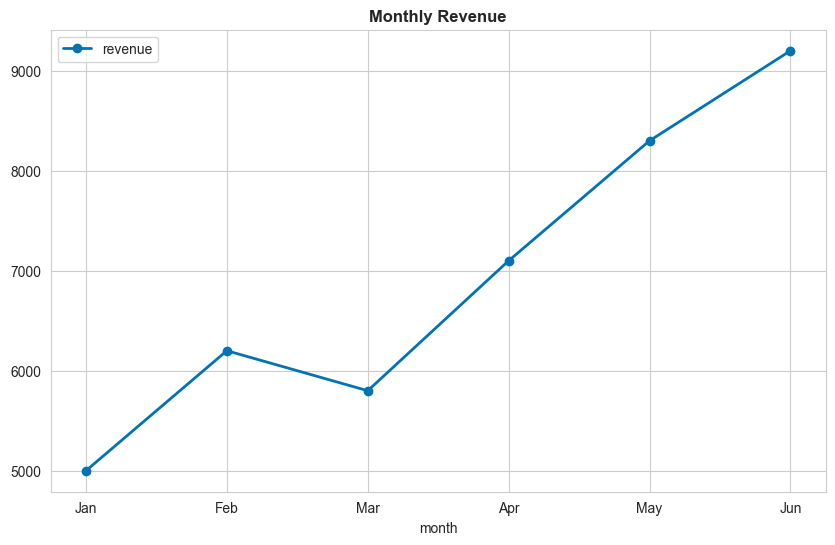

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))
sales.plot(x='month', y='revenue', kind='line', ax=ax, marker='o', linewidth=2)
ax.set_title('Monthly Revenue', fontweight='bold')

# Save as PNG (raster format – good for web)
plt.savefig('revenue_chart.png', dpi=150, bbox_inches='tight')

# Save as PDF (vector format – good for printing)
plt.savefig('revenue_chart.pdf', bbox_inches='tight')

# Save as SVG (vector format – editable)
plt.savefig('revenue_chart.svg', bbox_inches='tight')

# Save with high DPI for printing
plt.savefig('revenue_chart_print.png', dpi=300, bbox_inches='tight')

print("Chart saved successfully!")
plt.show()

**File Format Guide:**
- **PNG**: Web, presentations (raster, smaller file)
- **PDF**: Printing, documents (vector, scalable)
- **SVG**: Editing, web (vector, editable)
- **JPG**: Photos, web (raster, compressed)

---

## Common Customization Mistakes to Avoid

<Axes: xlabel='month'>

/Users/dks0790796/Downloads/Personal/Projects/Kaggle/Predict_Customer_Churn/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/dks0790796/Downloads/Personal/Projects/Kaggle/Predict_Customer_Churn/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


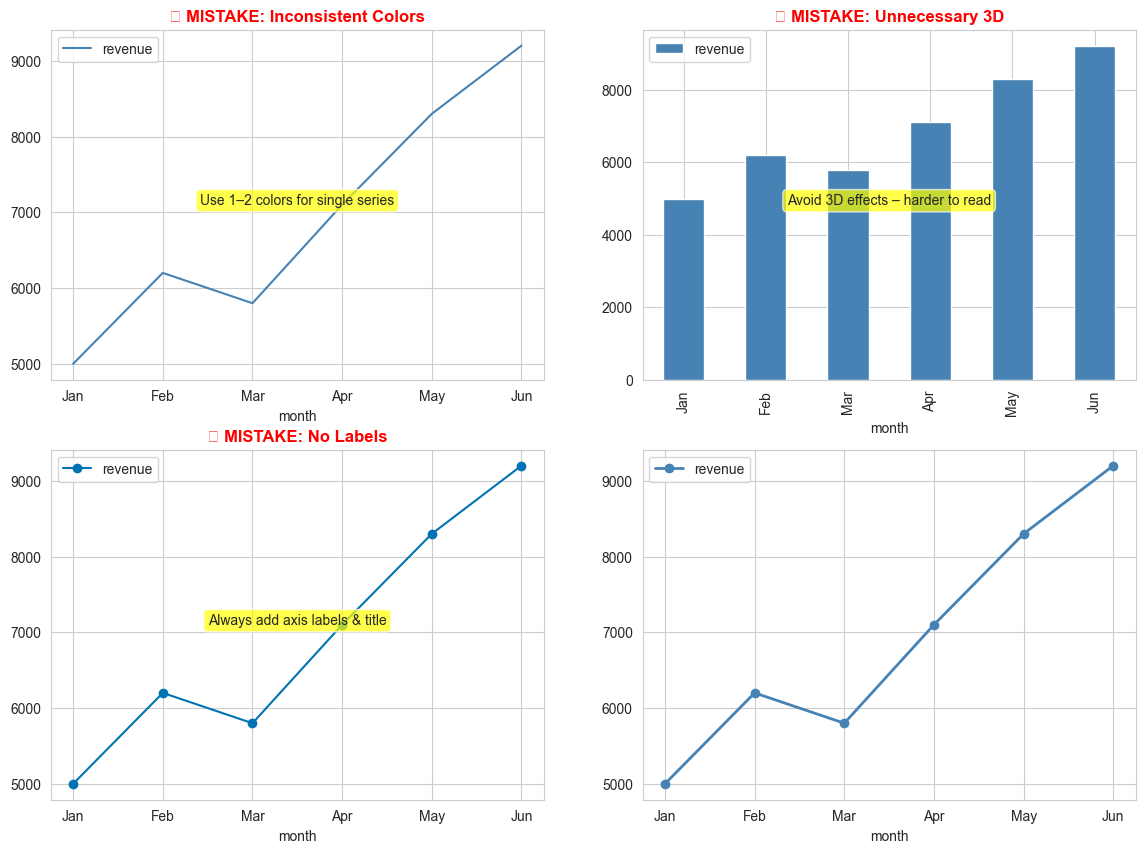

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ❌ MISTAKE 1: Too many colors (confusing)
ax = axes[0, 0]
sales.plot(x='month', y='revenue', kind='line', ax=ax, color='steelblue')
ax.set_title('❌ MISTAKE: Inconsistent Colors', fontweight='bold', color='red')
ax.text(0.5, 0.5, 'Use 1–2 colors for single series',
        transform=ax.transAxes, ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# ❌ MISTAKE 2: Unnecessary 3D effects
ax = axes[0, 1]
sales.plot(x='month', y='revenue', kind='bar', ax=ax, color='steelblue')
ax.set_title('❌ MISTAKE: Unnecessary 3D', fontweight='bold', color='red')
ax.text(0.5, 0.5, 'Avoid 3D effects – harder to read',
        transform=ax.transAxes, ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# ❌ MISTAKE 3: Missing labels
ax = axes[1, 0]
sales.plot(x='month', y='revenue', kind='line', ax=ax, marker='o')
ax.set_title('❌ MISTAKE: No Labels', fontweight='bold', color='red')
ax.text(0.5, 0.5, 'Always add axis labels & title',
        transform=ax.transAxes, ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# ✅ CORRECT: Clean, clear, focused
ax = axes[1, 1]
sales.plot(x='month', y='revenue', kind='line', ax=ax,
           marker='o', linewidth=2, color='steelblue')

---

# Exercises

Test your understanding of this chapter's concepts.

### Exercise 1: Scatter and Box Plots with Seaborn

Create a scatter plot and a box plot using Seaborn to explore a small sales dataset. Use hue to add a categorical dimension to the scatter plot, and display the box plot to compare distributions across categories.

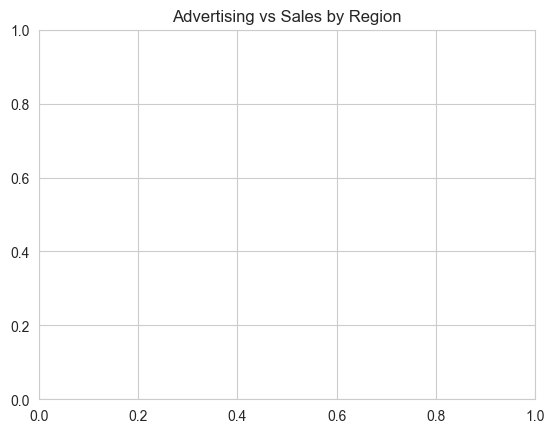

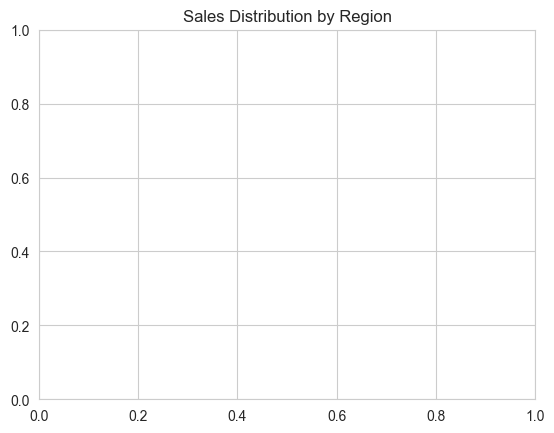

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Sample sales data
df = pd.DataFrame({
    'region': ['North', 'South', 'North', 'East', 'South', 'East', 'North', 'South', 'East', 'North'],
    'sales': [250, 180, 320, 210, 150, 290, 400, 220, 175, 310],
    'advertising': [30, 20, 45, 25, 18, 40, 55, 28, 22, 42],
    'profit': [80, 55, 110, 70, 45, 95, 130, 72, 58, 105]
})

# TODO: Create a scatter plot with 'advertising' on x-axis, 'sales' on y-axis,
# and color points by 'region' using the hue parameter


plt.title('Advertising vs Sales by Region')
plt.show()

# TODO: Create a box plot showing the distribution of 'sales' for each 'region'


plt.title('Sales Distribution by Region')
plt.show()

### Exercise 2: Heatmap of Correlations

Compute the correlation matrix of a numeric DataFrame and visualize it as a Seaborn heatmap. Customize the heatmap by annotating each cell with its correlation value and choosing an appropriate color palette.

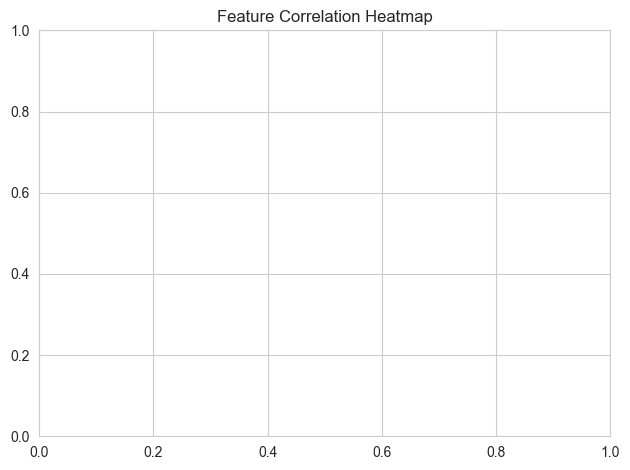

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
df = pd.DataFrame({
    'temperature': np.random.uniform(15, 35, 50),
    'humidity': np.random.uniform(30, 90, 50),
    'wind_speed': np.random.uniform(0, 20, 50),
    'ice_cream_sales': np.random.uniform(100, 500, 50),
    'sunscreen_sales': np.random.uniform(50, 300, 50)
})
# Add a realistic correlation
df['ice_cream_sales'] = df['ice_cream_sales'] + df['temperature'] * 8
df['sunscreen_sales'] = df['sunscreen_sales'] + df['temperature'] * 5

# TODO: Compute the correlation matrix of df and store it in a variable called 'corr_matrix'


# TODO: Create a heatmap of corr_matrix using sns.heatmap()
# - Set annot=True to show correlation values in each cell
# - Use the 'coolwarm' color palette
# - Round annotation values to 2 decimal places using fmt='.2f'


plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Exercise 3: Violin Plot and Count Plot for Categorical Analysis

Use Seaborn to create a violin plot comparing score distributions across departments, and a count plot showing how many employees fall into each performance category. These two plots together reveal both distribution shape and category frequency.

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(7)
df = pd.DataFrame({
    'department': np.random.choice(['Engineering', 'Marketing', 'HR'], size=60),
    'score': np.concatenate([
        np.random.normal(75, 10, 20),
        np.random.normal(65, 15, 20),
        np.random.normal(70, 8, 20)
    ]),
    'performance': np.random.choice(['Low', 'Medium', 'High'], size=60)
})

# TODO: Create a figure with 1 row and 2 columns of subplots using plt.subplots()
# Set the figure size to (14, 5)


# TODO: In the first subplot (axes index 0), create a violin plot
# showing 'score' distribution for each 'department'
# Use the ax parameter to place it in the correct subplot


# TODO: In the second subplot (axes index 1), create a count plot
# showing the frequency of each 'performance' category
# Color the bars by 'performance' using the hue parameter
# Use the ax parameter to place it in the correct subplot


plt.suptitle('Employee Performance Analysis', fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### Exercise 4: Complete Analysis Workflow with Pair Plot and Customization

Build a complete exploratory analysis workflow: first create a pair plot to examine multivariate relationships in a health dataset, then produce a customized line plot tracking average metrics over time. Apply Seaborn themes and color palettes to make the plots publication-ready.

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(21)
health_df = pd.DataFrame({
    'age': np.random.randint(20, 65, 80),
    'bmi': np.random.uniform(18, 35, 80),
    'blood_pressure': np.random.uniform(70, 130, 80),
    'cholesterol': np.random.uniform(150, 280, 80),
    'group': np.random.choice(['Control', 'Treatment'], size=80)
})

monthly_df = pd.DataFrame({
    'month': range(1, 13),
    'avg_bmi_control': np.random.uniform(26, 28, 12),
    'avg_bmi_treatment': np.linspace(27, 24, 12) + np.random.normal(0, 0.2, 12)
})

# TODO: Set the Seaborn theme to 'whitegrid' using sns.set_theme()


# TODO: Create a pair plot of health_df using only the numeric columns
# ['age', 'bmi', 'blood_pressure', 'cholesterol']
# Color the points by 'group' using the hue parameter
# Use the 'husl' palette


plt.suptitle('Health Metrics Pair Plot', y=1.02)
plt.show()

# TODO: Create a line plot showing both 'avg_bmi_control' and 'avg_bmi_treatment'
# over 'month' from monthly_df
# Plot each as a separate sns.lineplot() call with different colors and labels
# Add a legend, axis labels ('Month' and 'Average BMI'), and a title


plt.show()

<Figure size 640x480 with 0 Axes>

---

# Solutions

*Scroll down only after you've attempted the exercises above.*

<br><br><br><br><br><br><br><br><br><br>

### Solution 1: Scatter and Box Plots with Seaborn

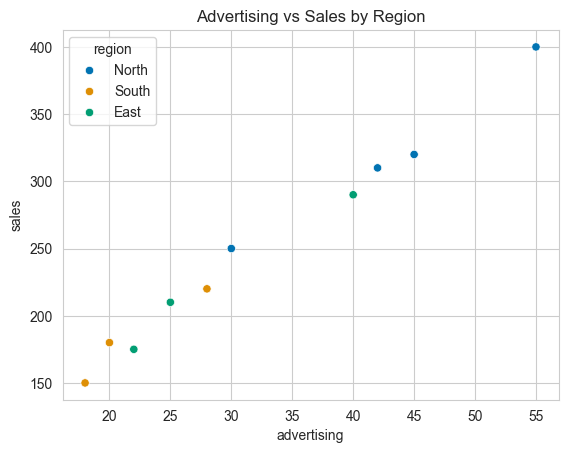

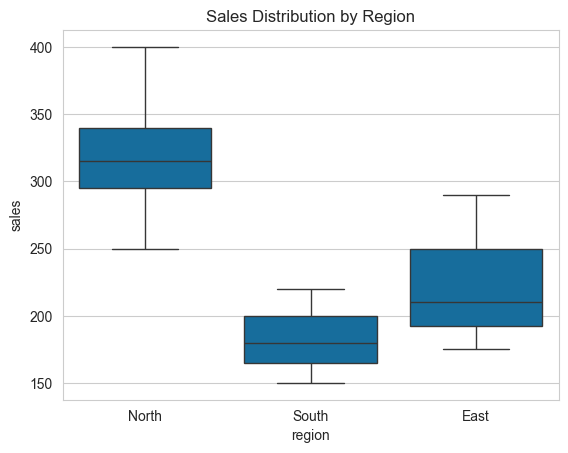

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Sample sales data
df = pd.DataFrame({
    'region': ['North', 'South', 'North', 'East', 'South', 'East', 'North', 'South', 'East', 'North'],
    'sales': [250, 180, 320, 210, 150, 290, 400, 220, 175, 310],
    'advertising': [30, 20, 45, 25, 18, 40, 55, 28, 22, 42],
    'profit': [80, 55, 110, 70, 45, 95, 130, 72, 58, 105]
})

# Create a scatter plot with 'advertising' on x-axis, 'sales' on y-axis,
# and color points by 'region' using the hue parameter
sns.scatterplot(data=df, x='advertising', y='sales', hue='region')
plt.title('Advertising vs Sales by Region')
plt.show()

# Create a box plot showing the distribution of 'sales' for each 'region'
sns.boxplot(data=df, x='region', y='sales')
plt.title('Sales Distribution by Region')
plt.show()

### Solution 2: Heatmap of Correlations

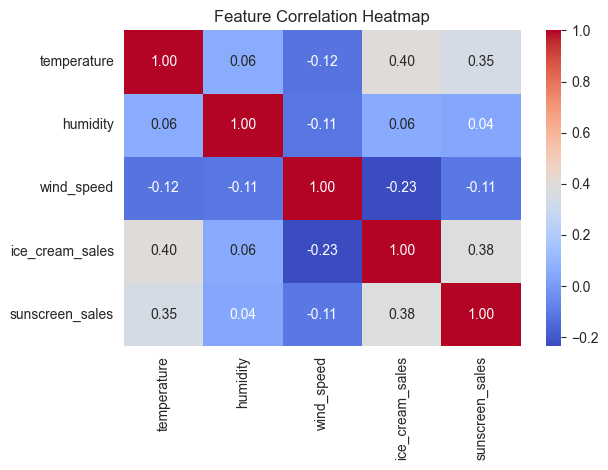

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
df = pd.DataFrame({
    'temperature': np.random.uniform(15, 35, 50),
    'humidity': np.random.uniform(30, 90, 50),
    'wind_speed': np.random.uniform(0, 20, 50),
    'ice_cream_sales': np.random.uniform(100, 500, 50),
    'sunscreen_sales': np.random.uniform(50, 300, 50)
})
# Add a realistic correlation
df['ice_cream_sales'] = df['ice_cream_sales'] + df['temperature'] * 8
df['sunscreen_sales'] = df['sunscreen_sales'] + df['temperature'] * 5

# Compute the correlation matrix of df
corr_matrix = df.corr()

# Create a heatmap of corr_matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Solution 3: Violin Plot and Count Plot for Categorical Analysis

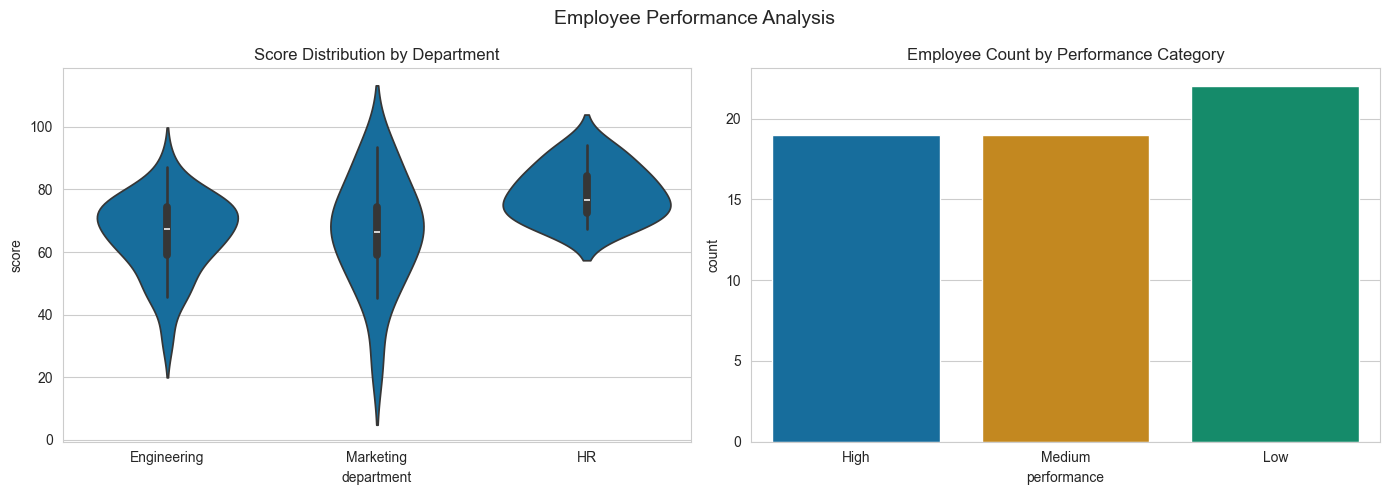

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(7)
df = pd.DataFrame({
    'department': np.random.choice(['Engineering', 'Marketing', 'HR'], size=60),
    'score': np.concatenate([
        np.random.normal(75, 10, 20),
        np.random.normal(65, 15, 20),
        np.random.normal(70, 8, 20)
    ]),
    'performance': np.random.choice(['Low', 'Medium', 'High'], size=60)
})

# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# In the first subplot, create a violin plot
sns.violinplot(data=df, x='department', y='score', ax=axes[0])
axes[0].set_title('Score Distribution by Department')

# In the second subplot, create a count plot
sns.countplot(data=df, x='performance', hue='performance', ax=axes[1])
axes[1].set_title('Employee Count by Performance Category')

plt.suptitle('Employee Performance Analysis', fontsize=14)
plt.tight_layout()
plt.show()

### Solution 4: Complete Analysis Workflow with Pair Plot and Customization

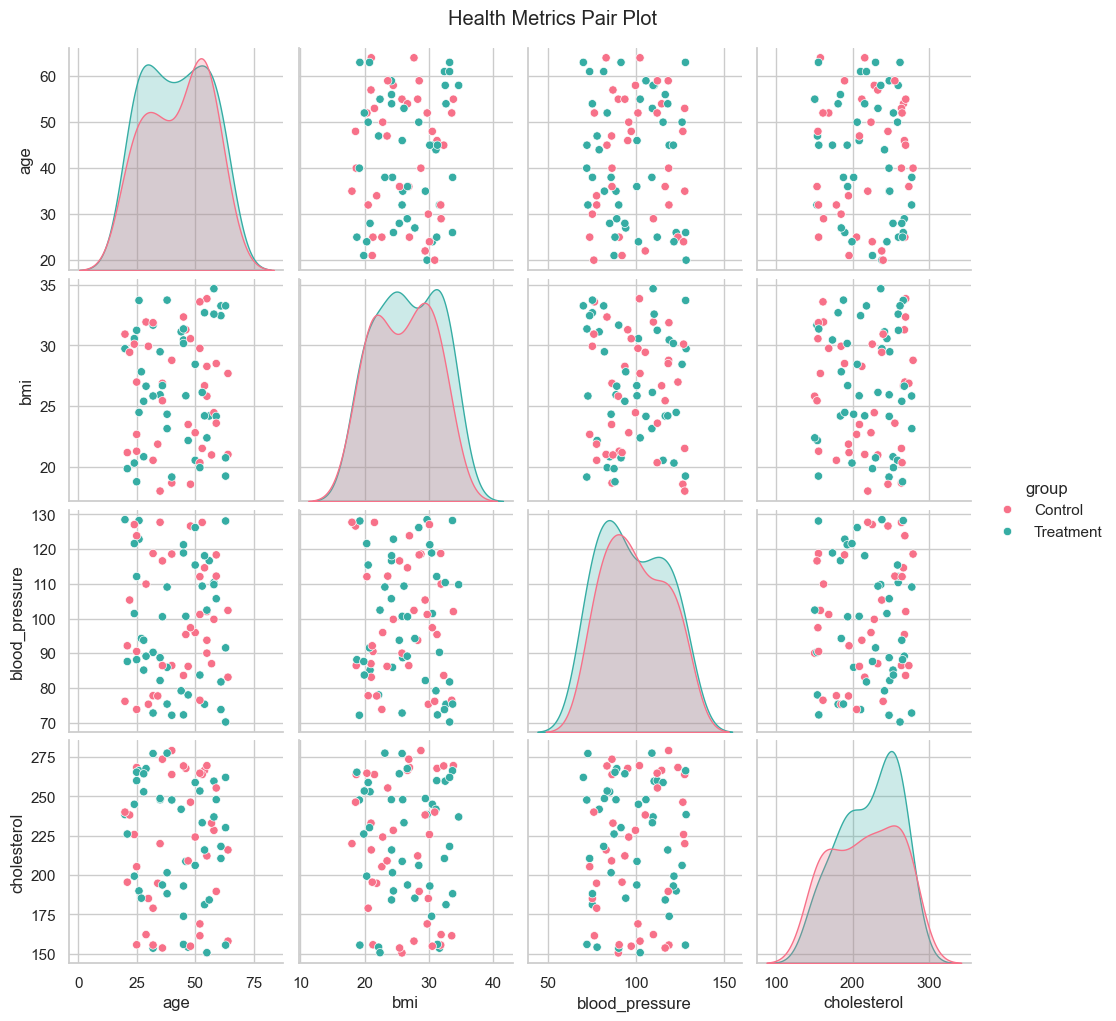

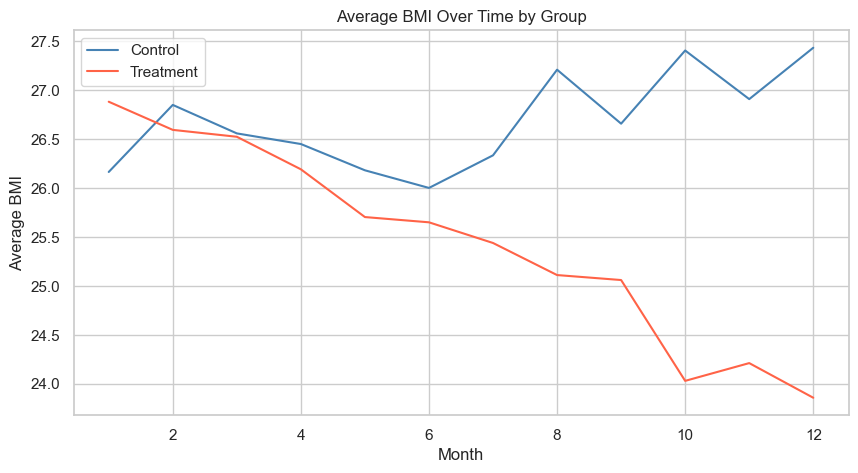

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(21)
health_df = pd.DataFrame({
    'age': np.random.randint(20, 65, 80),
    'bmi': np.random.uniform(18, 35, 80),
    'blood_pressure': np.random.uniform(70, 130, 80),
    'cholesterol': np.random.uniform(150, 280, 80),
    'group': np.random.choice(['Control', 'Treatment'], size=80)
})

monthly_df = pd.DataFrame({
    'month': range(1, 13),
    'avg_bmi_control': np.random.uniform(26, 28, 12),
    'avg_bmi_treatment': np.linspace(27, 24, 12) + np.random.normal(0, 0.2, 12)
})

# Set the Seaborn theme to 'whitegrid'
sns.set_theme(style='whitegrid')

# Create a pair plot of health_df using only numeric columns, colored by 'group'
sns.pairplot(
    health_df[['age', 'bmi', 'blood_pressure', 'cholesterol', 'group']],
    hue='group',
    palette='husl'
)
plt.suptitle('Health Metrics Pair Plot', y=1.02)
plt.show()

# Create a line plot for both groups over months
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_df, x='month', y='avg_bmi_control',
             color='steelblue', label='Control')
sns.lineplot(data=monthly_df, x='month', y='avg_bmi_treatment',
             color='tomato', label='Treatment')
plt.xlabel('Month')
plt.ylabel('Average BMI')
plt.title('Average BMI Over Time by Group')
plt.legend()
plt.show()